## Problem Statement

### Context

AllLife Bank is a US bank that has a growing customer base. The majority of these customers are liability customers (depositors) with varying sizes of deposits. The number of customers who are also borrowers (asset customers) is quite small, and the bank is interested in expanding this base rapidly to bring in more loan business and in the process, earn more through the interest on loans. In particular, the management wants to explore ways of converting its liability customers to personal loan customers (while retaining them as depositors).

A campaign that the bank ran last year for liability customers showed a healthy conversion rate of over 9% success. This has encouraged the retail marketing department to devise campaigns with better target marketing to increase the success ratio.

You as a Data scientist at AllLife bank have to build a model that will help the marketing department to identify the potential customers who have a higher probability of purchasing the loan.

### Objective

To predict whether a liability customer will buy personal loans, to understand which customer attributes are most significant in driving purchases, and identify which segment of customers to target more.

### Data Dictionary
* `ID`: Customer ID
* `Age`: Customer’s age in completed years
* `Experience`: #years of professional experience
* `Income`: Annual income of the customer (in thousand dollars)
* `ZIP Code`: Home Address ZIP code.
* `Family`: the Family size of the customer
* `CCAvg`: Average spending on credit cards per month (in thousand dollars)
* `Education`: Education Level. 1: Undergrad; 2: Graduate;3: Advanced/Professional
* `Mortgage`: Value of house mortgage if any. (in thousand dollars)
* `Personal_Loan`: Did this customer accept the personal loan offered in the last campaign? (0: No, 1: Yes)
* `Securities_Account`: Does the customer have securities account with the bank? (0: No, 1: Yes)
* `CD_Account`: Does the customer have a certificate of deposit (CD) account with the bank? (0: No, 1: Yes)
* `Online`: Do customers use internet banking facilities? (0: No, 1: Yes)
* `CreditCard`: Does the customer use a credit card issued by any other Bank (excluding All life Bank)? (0: No, 1: Yes)

## Importing necessary libraries

In [1]:
# Installing the libraries with the specified version.
# !pip install numpy==1.25.2 pandas==1.5.3 matplotlib==3.7.1 seaborn==0.13.1 scikit-learn==1.2.2 sklearn-pandas==2.2.0 -q --user

# This has been updated with info found in the discussion replies of question from Biao Song on 11/4/25.

# !pip install pandas==2.2.2 numpy==2.0.2 matplotlib==3.10.0 seaborn==0.13.2 scikit-learn==1.6.1 -q --user

# Possible required instalation needed according to project's FAQ.

# !pip install nb-black

**Note**:

1. After running the above cell, kindly restart the notebook kernel (for Jupyter Notebook) or runtime (for Google Colab), write the relevant code for the project from the next cell, and run all cells sequentially from the next cell.

2. On executing the above line of code, you might see a warning regarding package dependencies. This error message can be ignored as the above code ensures that all necessary libraries and their dependencies are maintained to successfully execute the code in this notebook.

In [2]:
# Libraries to help with reading and manipulating data
import pandas as pd
import numpy as np

# libaries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline



# Library to split data
from sklearn.model_selection import train_test_split

# To build model for prediction
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree

# To get diferent metric scores
from sklearn.metrics import (
    f1_score,
    accuracy_score,
    recall_score,
    precision_score,
    confusion_matrix,
)

# to suppress unnecessary warnings
import warnings
warnings.filterwarnings("ignore")

## Loading the dataset

In [3]:
# uncomment and run the below code snippets if the dataset is present in the Google Drive
# from google.colab import drive
# drive.mount('/content/drive')

In [4]:
# Reading the data from csv file and assigning it to a DataFrame .

original_data = pd.read_csv('Loan_Modelling.csv')

# Createing a work copy of the Dataframe

df = original_data.copy()

## Data Overview

### Sanity Check

In [5]:
# View the first 5 rows of the dataset

df.head( )

,ID,Age,Experience,Income,ZIPCode,Family,CCAvg,Education,Mortgage,Personal_Loan,Securities_Account,CD_Account,Online,CreditCard
0,1,25,1,49,91107,4,1.6,1,0,0,1,0,0,0
1,2,45,19,34,90089,3,1.5,1,0,0,1,0,0,0
2,3,39,15,11,94720,1,1.0,1,0,0,0,0,0,0
3,4,35,9,100,94112,1,2.7,2,0,0,0,0,0,0
4,5,35,8,45,91330,4,1.0,2,0,0,0,0,0,1


In [6]:
# View the last 5 rows of the dataset

df.tail()

,ID,Age,Experience,Income,ZIPCode,Family,CCAvg,Education,Mortgage,Personal_Loan,Securities_Account,CD_Account,Online,CreditCard
4995,4996,29,3,40,92697,1,1.9,3,0,0,0,0,1,0
4996,4997,30,4,15,92037,4,0.4,1,85,0,0,0,1,0
4997,4998,63,39,24,93023,2,0.3,3,0,0,0,0,0,0
4998,4999,65,40,49,90034,3,0.5,2,0,0,0,0,1,0
4999,5000,28,4,83,92612,3,0.8,1,0,0,0,0,1,1


In [7]:
# View the shape of the dataset

df.shape

(5000, 14)

* The dataset has 5000 rows and 14 columns

In [8]:
# Viewing the different data types.

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ID                  5000 non-null   int64  
 1   Age                 5000 non-null   int64  
 2   Experience          5000 non-null   int64  
 3   Income              5000 non-null   int64  
 4   ZIPCode             5000 non-null   int64  
 5   Family              5000 non-null   int64  
 6   CCAvg               5000 non-null   float64
 7   Education           5000 non-null   int64  
 8   Mortgage            5000 non-null   int64  
 9   Personal_Loan       5000 non-null   int64  
 10  Securities_Account  5000 non-null   int64  
 11  CD_Account          5000 non-null   int64  
 12  Online              5000 non-null   int64  
 13  CreditCard          5000 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 547.0 KB


* There are 14 numerical vairables, and no categorical (object) variables.
* There are no missing values as number of entries = number of rows in every column, but we will verify next.

In [9]:
# Verify missing values.

df.isnull().sum()

ID                    0
Age                   0
Experience            0
Income                0
ZIPCode               0
Family                0
CCAvg                 0
Education             0
Mortgage              0
Personal_Loan         0
Securities_Account    0
CD_Account            0
Online                0
CreditCard            0
dtype: int64

* As expected no missing values, so check for duplicates.

In [10]:
# Checking if there are any duplicates

df.duplicated().sum()

np.int64(0)

* There are no duplicated entries.

In [11]:
# Getting more detailed information of all the dataset

df.describe(include='all').T

,count,mean,std,min,25%,50%,75%,max
ID,5000.0,2500.500000,1443.520003,1.0,1250.75,2500.5,3750.25,5000.0
Age,5000.0,45.338400,11.463166,23.0,35.00,45.0,55.00,67.0
Experience,5000.0,20.104600,11.467954,-3.0,10.00,20.0,30.00,43.0
Income,5000.0,73.774200,46.033729,8.0,39.00,64.0,98.00,224.0
ZIPCode,5000.0,93169.257000,1759.455086,90005.0,91911.00,93437.0,94608.00,96651.0
Family,5000.0,2.396400,1.147663,1.0,1.00,2.0,3.00,4.0
CCAvg,5000.0,1.937938,1.747659,0.0,0.70,1.5,2.50,10.0
Education,5000.0,1.881000,0.839869,1.0,1.00,2.0,3.00,3.0
Mortgage,5000.0,56.498800,101.713802,0.0,0.00,0.0,101.00,635.0
Personal_Loan,5000.0,0.096000,0.294621,0.0,0.00,0.0,0.00,1.0


* ID column may be droped as it doesn't add any value to the analysis.
* In Experience the lowest number is negative, so further analysis may be needed.
* ZIPCode should be treated more as a categorical value.
* CCAvg has a mean of 1.94 while Income and Mortgage have values of 73.77 and 56.50.  This is because CCAvg is based on months.

In [12]:
# Droping the Customer ID column before the EDA.

df = df.drop(['ID'], axis=1)

In [13]:
# Verify the new dataframe.

df.head()

,Age,Experience,Income,ZIPCode,Family,CCAvg,Education,Mortgage,Personal_Loan,Securities_Account,CD_Account,Online,CreditCard
0,25,1,49,91107,4,1.6,1,0,0,1,0,0,0
1,45,19,34,90089,3,1.5,1,0,0,1,0,0,0
2,39,15,11,94720,1,1.0,1,0,0,0,0,0,0
3,35,9,100,94112,1,2.7,2,0,0,0,0,0,0
4,35,8,45,91330,4,1.0,2,0,0,0,0,0,1


In [14]:
# Checking the values in Experience column.

df["Experience"].unique()

array([ 1, 19, 15,  9,  8, 13, 27, 24, 10, 39,  5, 23, 32, 41, 30, 14, 18,
       21, 28, 31, 11, 16, 20, 35,  6, 25,  7, 12, 26, 37, 17,  2, 36, 29,
        3, 22, -1, 34,  0, 38, 40, 33,  4, -2, 42, -3, 43])

In [15]:
# Checking for experience <0.

df[df["Experience"] < 0]["Experience"].unique()

array([-1, -2, -3])

* There are 3 negative values: -1, -2 and -3

In [16]:
# Correcting the experience values.

df["Experience"].replace(-1, 1, inplace=True)
df["Experience"].replace(-2, 2, inplace=True)
df["Experience"].replace(-3, 3, inplace=True)

In [17]:
# Verify values were updated.

df["Experience"].unique()

array([ 1, 19, 15,  9,  8, 13, 27, 24, 10, 39,  5, 23, 32, 41, 30, 14, 18,
       21, 28, 31, 11, 16, 20, 35,  6, 25,  7, 12, 26, 37, 17,  2, 36, 29,
        3, 22, 34,  0, 38, 40, 33,  4, 42, 43])

### Setting CCAvg, Income and Mortgage to same base.

In [18]:
# Convert CCAvg to an annual value to be on same scale as Income and Mortgage

df['CCAvg'] = df['CCAvg']*12

# check statistical value of CCAvg
df['CCAvg'].describe()

count    5000.000000
mean       23.255256
std        20.971908
min         0.000000
25%         8.400000
50%        18.000000
75%        30.000000
max       120.000000
Name: CCAvg, dtype: float64

### Working with ZIPCode column.

In [19]:
# Number of unique ZIP Codes in the dataset.

df["ZIPCode"].nunique()

467

* There are 467 different Zip Codes.

In [20]:
# Changing ZIPCode to string and getting unique values for the first 2 numbers.

df["ZIPCode"] = df["ZIPCode"].astype(str)

print(
    "Number of unique values if we take first two digits of ZIPCode: ",
    df["ZIPCode"].str[0:2].nunique(),
)

Number of unique values if we take first two digits of ZIPCode:  7


In [21]:
# Adding a new column to the dataset named Zone

df["Zone"] = df["ZIPCode"].str[0:2]

df["Zone"] = df["Zone"].astype("category")

In [22]:
#Identify unique values and counts for Zone

df['Zone'].unique()

['91', '90', '94', '92', '93', '95', '96']
Categories (7, object): ['90', '91', '92', '93', '94', '95', '96']

In [23]:
'''
According to Wikipedia*, US ZIP Codes starting with 9 are mainly for California, so:

    90xxx: Southern California (e.g., Los Angeles, Anaheim, Long Beach).  --------------------> Zone_1
    91xxx: Southern California (e.g., Riverside, San Bernardino, Pasadena, Santa Ana).--------> Zone_2
    92xxx: Southern California (e.g., San Diego, Chula Vista, Oceanside).  -------------------> Zone_3
    93xxx: Central California (e.g., Bakersfield, Fresno, Santa Barbara, Salinas).------------> Zone_4
    94xxx: Northern California (e.g., San Francisco, Oakland, San Jose, Palo Alto).-----------> Zone_5
    95xxx: Northern California (e.g., Sacramento, Stockton, Fairfield, Davis).----------------> Zone_6
    96xxx: Alaska, Hawaii, and U.S. territories (e.g., Anchorage, Juneau, Honolulu, Guam). ---> Zone_0

    Notice Zone_0 includes territories other than CA.
    
    *https://simple.wikipedia.org/wiki/List_of_ZIP_Code_prefixes#First_Digits

'''

'\nAccording to Wikipedia*, US ZIP Codes starting with 9 are mainly for California, so:\n\n    90xxx: Southern California (e.g., Los Angeles, Anaheim, Long Beach).  --------------------> Zone_1\n    91xxx: Southern California (e.g., Riverside, San Bernardino, Pasadena, Santa Ana).--------> Zone_2\n    92xxx: Southern California (e.g., San Diego, Chula Vista, Oceanside).  -------------------> Zone_3\n    93xxx: Central California (e.g., Bakersfield, Fresno, Santa Barbara, Salinas).------------> Zone_4\n    94xxx: Northern California (e.g., San Francisco, Oakland, San Jose, Palo Alto).-----------> Zone_5\n    95xxx: Northern California (e.g., Sacramento, Stockton, Fairfield, Davis).----------------> Zone_6\n    96xxx: Alaska, Hawaii, and U.S. territories (e.g., Anchorage, Juneau, Honolulu, Guam). ---> Zone_0\n\n    Notice Zone_0 includes territories other than CA.\n\n    *https://simple.wikipedia.org/wiki/List_of_ZIP_Code_prefixes#First_Digits\n\n'

In [24]:
# Analyzing Zone_0

print(
    "Number of unique values if we take first three digits of ZIPCode: ",
    df["ZIPCode"].str[0:3].nunique(),
)

Zone_0_plus_DC_and_Towns = df["ZIPCode"].str[0:3]


Number of unique values if we take first three digits of ZIPCode:  57


In [25]:
Zone_0_plus_DC_and_Towns.value_counts()

ZIPCode
900    375
921    279
950    267
945    264
941    257
943    257
947    251
920    248
940    242
913    222
926    182
956    162
902    161
917    150
958    141
931    134
939    102
951     96
946     89
928     81
949     75
911     71
927     62
923     60
930     58
925     49
907     45
934     43
919     41
957     40
906     38
935     36
904     35
955     32
916     29
910     29
960     29
905     28
953     26
959     19
908     19
954     19
933     18
937     18
948     17
924     17
944     13
914     13
952     13
922     10
936      8
942      7
912      7
966      6
961      5
918      3
903      2
Name: count, dtype: int64

* There are 6 people with APO adresses (966) (Army / Air Force Postal Office), so there is a probabilty they could be military deployed personnel, and or with different behavioural patterns due to different environment.

In [26]:
# Defining a Zone dictionary for value replacement and droping the ZIPCode column.
zone_dict = {'90':'Zone_1', '91':'Zone_2','92':'Zone_3','93':'Zone_4', '94':'Zone_5', '95':'Zone_6', '96':'Zone_0'}

df['Zone'] = df['Zone'].map(lambda x: zone_dict[x])

df = df.drop(['ZIPCode'], axis=1)


In [27]:
df.head()

,Age,Experience,Income,Family,CCAvg,Education,Mortgage,Personal_Loan,Securities_Account,CD_Account,Online,CreditCard,Zone
0,25,1,49,4,19.2,1,0,0,1,0,0,0,Zone_2
1,45,19,34,3,18.0,1,0,0,1,0,0,0,Zone_1
2,39,15,11,1,12.0,1,0,0,0,0,0,0,Zone_5
3,35,9,100,1,32.4,2,0,0,0,0,0,0,Zone_5
4,35,8,45,4,12.0,2,0,0,0,0,0,1,Zone_2


In [28]:
df['Zone'].value_counts()

Zone
Zone_5    1472
Zone_3     988
Zone_6     815
Zone_1     703
Zone_2     565
Zone_4     417
Zone_0      40
Name: count, dtype: int64

In [29]:
df['Zone'].value_counts(normalize=True)

Zone
Zone_5    0.2944
Zone_3    0.1976
Zone_6    0.1630
Zone_1    0.1406
Zone_2    0.1130
Zone_4    0.0834
Zone_0    0.0080
Name: proportion, dtype: float64

* Around 45% of the people have their address in Northern California (29.4% Zone_5, 16.3% Zone_6); 46% have theirs in Southern California (19.8% Zone_3, 14% Zone_1, 11.3% Zone_2); 8.3% in Central California; and 0.8% in Zone_0.

In [30]:
# Casting variables as categorical.

cat_col_names = ["Education", "Personal_Loan", "Securities_Account", "CD_Account", "Online", "CreditCard"]

df[cat_col_names] = df[cat_col_names].astype('category')

## Exploratory Data Analysis.

- EDA is an important part of any project involving data.
- It is important to investigate and understand the data better before building a model with it.
- A few questions have been mentioned below which will help you approach the analysis in the right manner and generate insights from the data.
- A thorough analysis of the data, in addition to the questions mentioned below, should be done.

**Questions**:

1. What is the distribution of mortgage attribute? Are there any noticeable patterns or outliers in the distribution?
2. How many customers have credit cards?
3. What are the attributes that have a strong correlation with the target attribute (personal loan)?
4. How does a customer's interest in purchasing a loan vary with their age?
5. How does a customer's interest in purchasing a loan vary with their education?

### Univariate Analysis

In [31]:
# Function to create Boxplot and Histogram combined.

def histogram_boxplot(data, feature, figsize=(12, 7), kde=False, bins=None):
    """
    Boxplot and histogram combined

    data: dataframe
    feature: dataframe column
    figsize: size of figure (default (12,7))
    kde: whether to show the density curve (default False)
    bins: number of bins for histogram (default None)
    """
    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2,  # Number of rows of the subplot grid= 2
        sharex=True,  # x-axis will be shared among all subplots
        gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=figsize,
    )  # creating the 2 subplots
    sns.boxplot(
        data=data, x=feature, ax=ax_box2, showmeans=True, color="violet"
    )  # boxplot will be created and a star will indicate the mean value of the column
    sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2, bins=bins, palette="winter"
    ) if bins else sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2
    )  # For histogram
    ax_hist2.axvline(
        data[feature].mean(), color="green", linestyle="--"
    )  # Add mean to the histogram
    ax_hist2.axvline(
        data[feature].median(), color="black", linestyle="-"
    )  # Add median to the histogram

In [32]:
# Function to create labeled barplots


def labeled_barplot(data, feature, perc=False, n=None):
    """
    Barplot with percentage at the top

    data: dataframe
    feature: dataframe column
    perc: whether to display percentages instead of count (default is False)
    n: displays the top n category levels (default is None, i.e., display all levels)
    """

    total = len(data[feature])  # length of the column
    count = data[feature].nunique()
    if n is None:
        plt.figure(figsize=(count + 1, 5))
    else:
        plt.figure(figsize=(n + 1, 5))

    plt.xticks(rotation=90, fontsize=15)
    ax = sns.countplot(
        data=data,
        x=feature,
        palette="Paired",
        order=data[feature].value_counts().index[:n].sort_values(),
    )

    for p in ax.patches:
        if perc == True:
            label = "{:.1f}%".format(
                100 * p.get_height() / total
            )  # percentage of each class of the category
        else:
            label = p.get_height()  # count of each level of the category

        x = p.get_x() + p.get_width() / 2  # width of the plot
        y = p.get_height()  # height of the plot

        ax.annotate(
            label,
            (x, y),
            ha="center",
            va="center",
            size=12,
            xytext=(0, 5),
            textcoords="offset points",
        )  # annotate the percentage

    plt.show()  # show the plot

#### Observations on Age

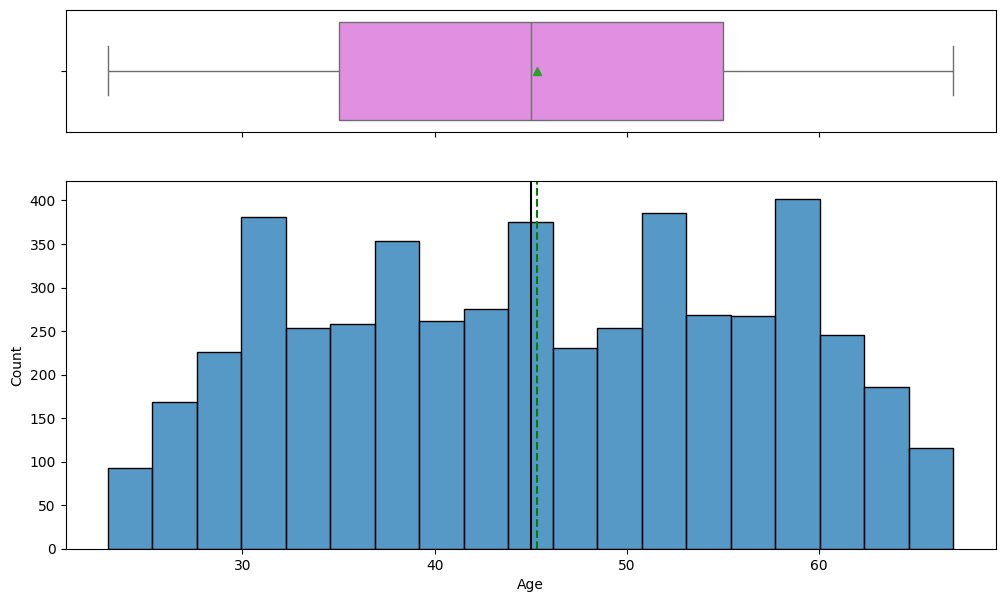

In [33]:
histogram_boxplot(df, "Age")

* Age ranges from 23 to 67 years old. The distribution is almost symetrical as mean (45.3) is almost equal as median (45).
* There are no outliers visible in the box plot.

#### Observations on Experience

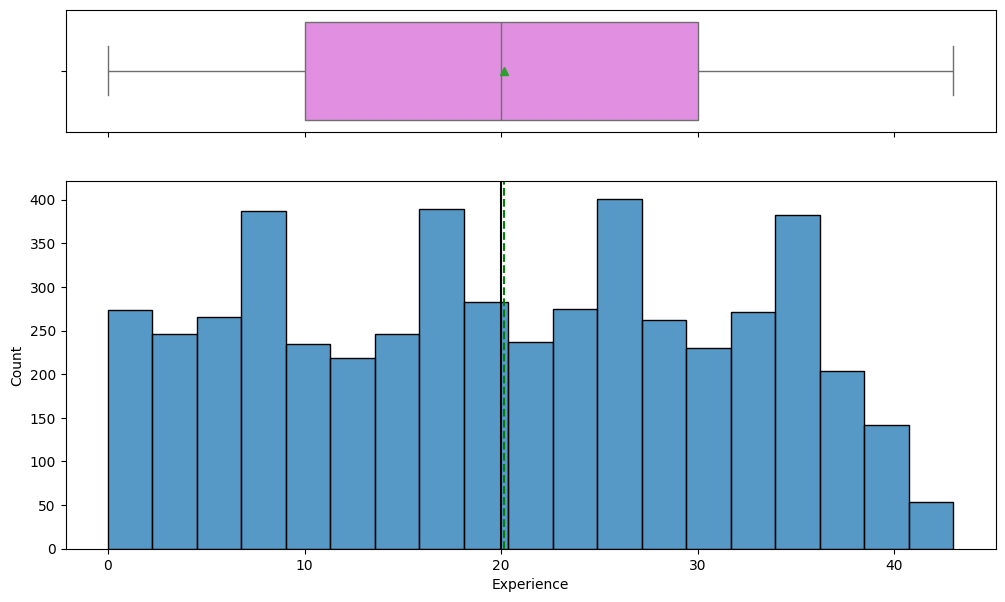

In [34]:
histogram_boxplot(df, 'Experience')

* Experience ranges from 0 to 43 years. The distribution is almost symetrical as mean (20.13) is almost equal as median (20).
* There are no outliers visible in the box plot.

#### Observations on Income

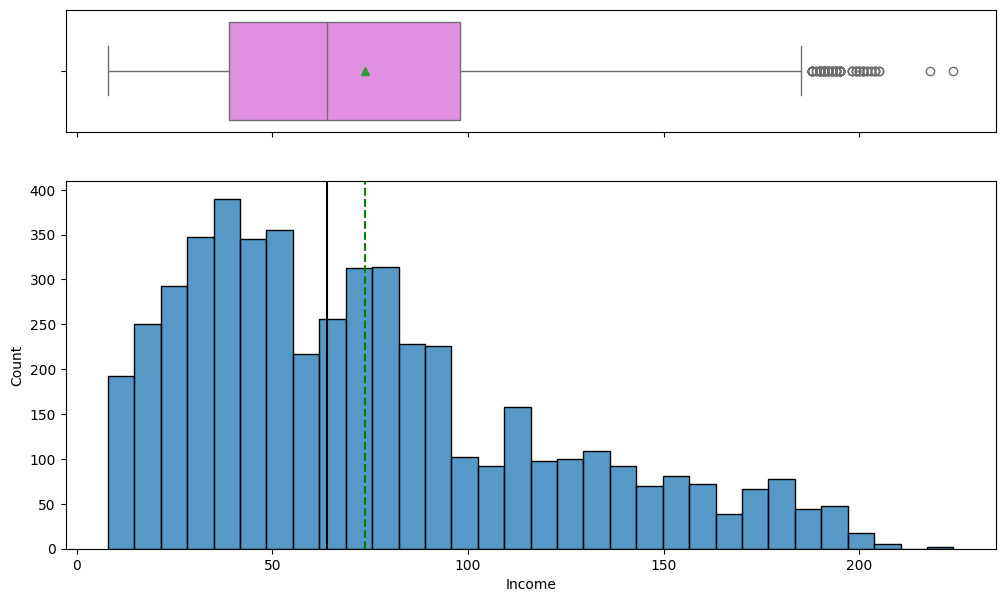

In [35]:
histogram_boxplot(df, 'Income')

* Income ranges from 8 to 224K USD. The distribution is right skewed with a mean (73.77) is more than the median (64).
* There are several outliers visible in the box plot in the upper whisker, none in the lower.

#### Observations on CCAvg

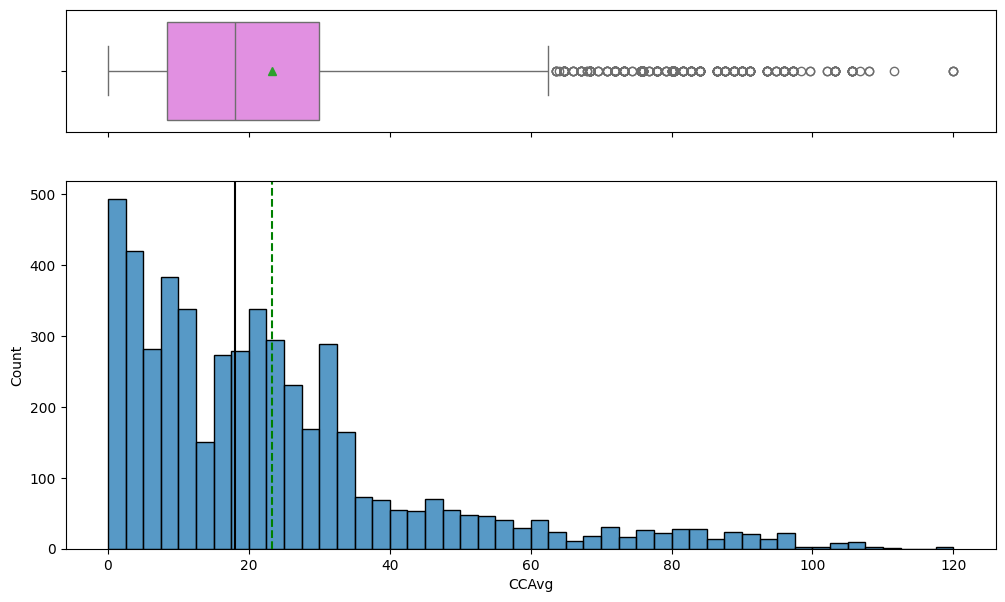

In [36]:
histogram_boxplot(df,'CCAvg')

* CCAvg (annualized) ranges from 0 to 120K USD. The distribution is right skewed with a mean (23.25) is more than the median (18).
* There are several outliers visible in the box plot in the upper whisker, none in the lower.

#### Observations on Mortgage

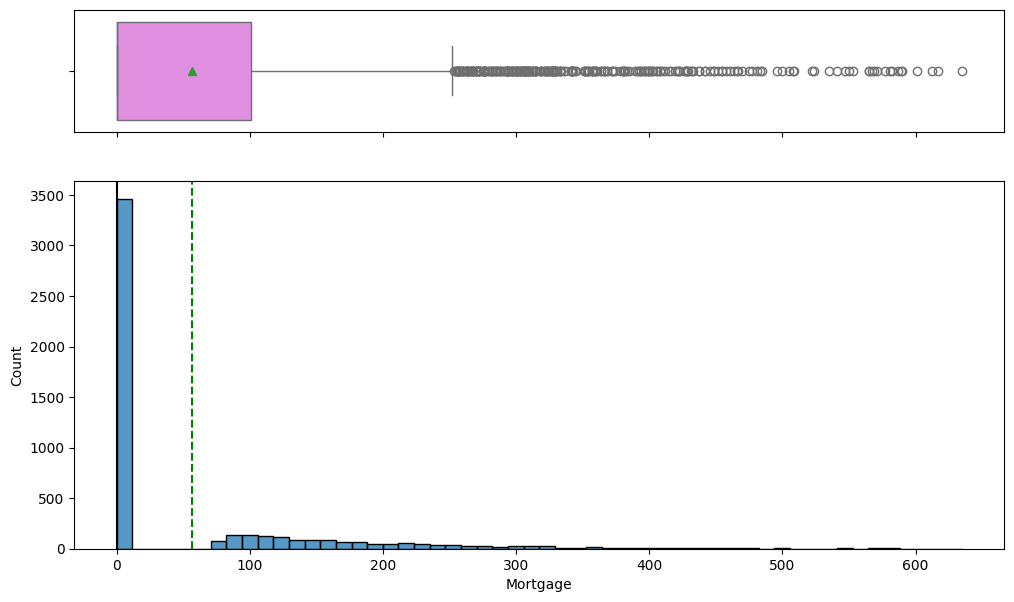

In [37]:
histogram_boxplot(df, 'Mortgage')  ## Question 1

In [38]:
df['Mortgage'].value_counts()

Mortgage
0      3462
98       17
89       16
91       16
119      16
       ... 
550       1
283       1
612       1
590       1
541       1
Name: count, Length: 347, dtype: int64

* Mortgage ranges from 89 to 635K USD. The distribution is right skewed with a mean (56.5) is more than the median (0).
* A lot of people (3462) does not have a mortgage.
* There are several outliers visible in the box plot in the upper whisker, none in the lower.

#### Observations on Family

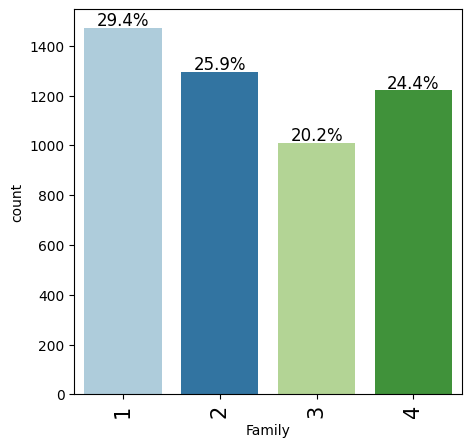

In [39]:
labeled_barplot(df, "Family", perc=True)

* Single-member family is most common with 29.4%, but other values are very near.

#### Observations on Education

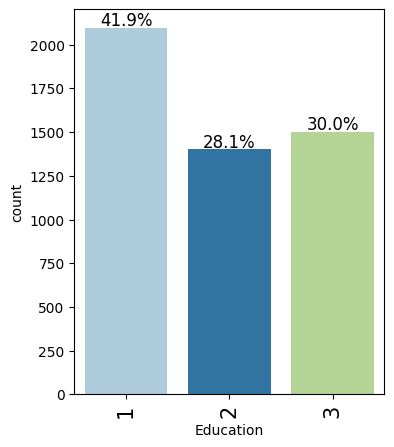

In [40]:
labeled_barplot(df, "Education", perc=True)

* Majority of customers are Undergraduate (1), followed by Professional (3) and Graduate (2).

* Graduates and Professionals (58.1%) are more likely to opt for loans.

#### Observations on Securities_Account

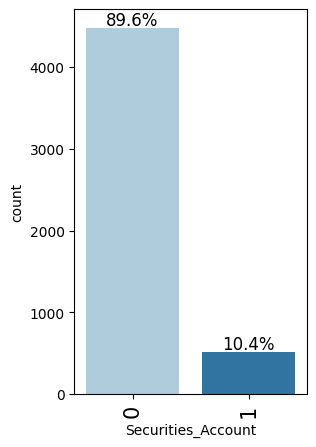

In [41]:
labeled_barplot(df, "Securities_Account", perc=True)

In [42]:
df['Securities_Account'].value_counts()

Securities_Account
0    4478
1     522
Name: count, dtype: int64

* There are 4478 (89.9%) customers that don’t have a securities account.

#### Observations on CD_Account

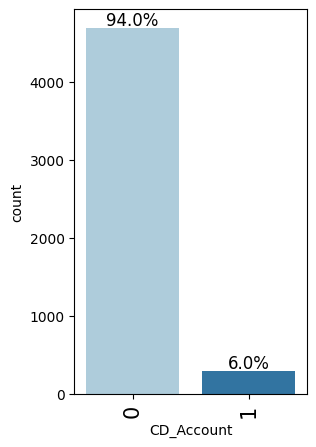

In [43]:
labeled_barplot(df, "CD_Account", perc=True)

In [44]:
df['CD_Account'].value_counts()

CD_Account
0    4698
1     302
Name: count, dtype: int64

* There are 4698 (94%) customers that don’t have certificate of deposit.

#### Observations on Online

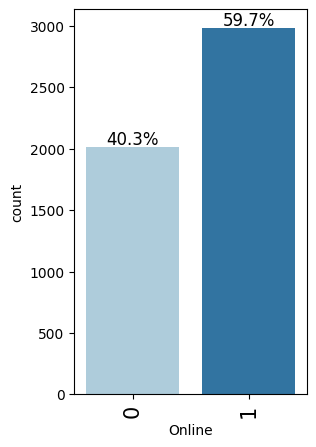

In [45]:
labeled_barplot(df, "Online", perc=True)

* Almost 60% of the customers use online banking.

#### Observation on CreditCard

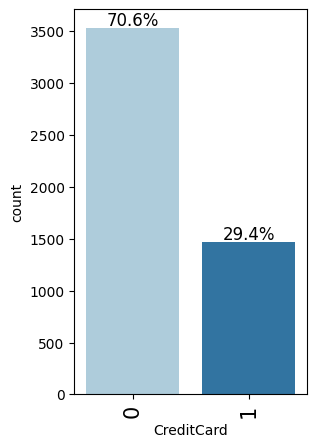

In [46]:
labeled_barplot(df, "CreditCard", perc=True)

In [47]:
# Verify number of customers that use credit cards issued by any other Bank (excluding All life Bank).  - Question 2

df['CreditCard'].value_counts()

CreditCard
0    3530
1    1470
Name: count, dtype: int64

* Around 1470 (29.4%) customers have and use credit cards issued by other banks.

#### Observation on Zone

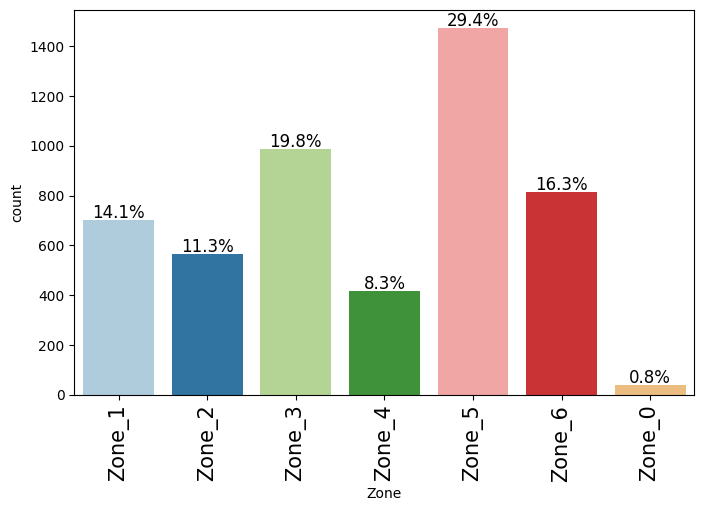

In [48]:
labeled_barplot(df, "Zone", perc=True)

* Around 45% of the people have their address in Northern California (29.4% Zone_5, 16.3% Zone_6); 46% have theirs in Southern California (19.8% Zone_3, 14% Zone_1, 11.3% Zone_2); 8.3% in Central California; and 0.8% in Zone_0.

#### Observations on Personal_Loan

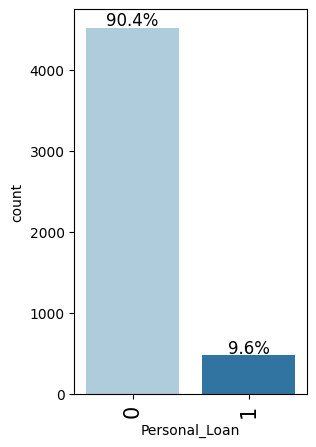

In [49]:
labeled_barplot(df, "Personal_Loan", perc=True)

In [50]:
df['Personal_Loan'].value_counts()

Personal_Loan
0    4520
1     480
Name: count, dtype: int64

* About 9.6% (480) of customers have accepted personal loans (target).

* There is class imbalance, which should be considered during modeling.

### Bivariate and Multivariate Analysis

In [51]:
def stacked_barplot(data, predictor, target):
    """
    Print the category counts and plot a stacked bar chart

    data: dataframe
    predictor: independent variable
    target: target variable
    """
    count = data[predictor].nunique()
    sorter = data[target].value_counts().index[-1]
    tab1 = pd.crosstab(data[predictor], data[target], margins=True).sort_values(
        by=sorter, ascending=False
    )
    print(tab1)
    print("-" * 120)
    tab = pd.crosstab(data[predictor], data[target], normalize="index").sort_values(
        by=sorter, ascending=False
    )
    tab.plot(kind="bar", stacked=True, figsize=(count + 5, 5))
    plt.legend(
        loc="lower left", frameon=False,
    )
    plt.legend(loc="upper left", bbox_to_anchor=(1, 1))
    plt.show()

In [52]:
### function to plot distributions wrt target


def distribution_plot_wrt_target(data, predictor, target):

    fig, axs = plt.subplots(2, 2, figsize=(12, 10))

    target_uniq = data[target].unique()

    axs[0, 0].set_title("Distribution of target for target=" + str(target_uniq[0]))
    sns.histplot(
        data=data[data[target] == target_uniq[0]],
        x=predictor,
        kde=True,
        ax=axs[0, 0],
        color="teal",
        stat="density",
    )

    axs[0, 1].set_title("Distribution of target for target=" + str(target_uniq[1]))
    sns.histplot(
        data=data[data[target] == target_uniq[1]],
        x=predictor,
        kde=True,
        ax=axs[0, 1],
        color="orange",
        stat="density",
    )

    axs[1, 0].set_title("Boxplot w.r.t target")
    sns.boxplot(data=data, x=target, y=predictor, ax=axs[1, 0], palette="gist_rainbow")

    axs[1, 1].set_title("Boxplot (without outliers) w.r.t target")
    sns.boxplot(
        data=data,
        x=target,
        y=predictor,
        ax=axs[1, 1],
        showfliers=False,
        palette="gist_rainbow",
    )

    plt.tight_layout()
    plt.show()

#### Correlation check

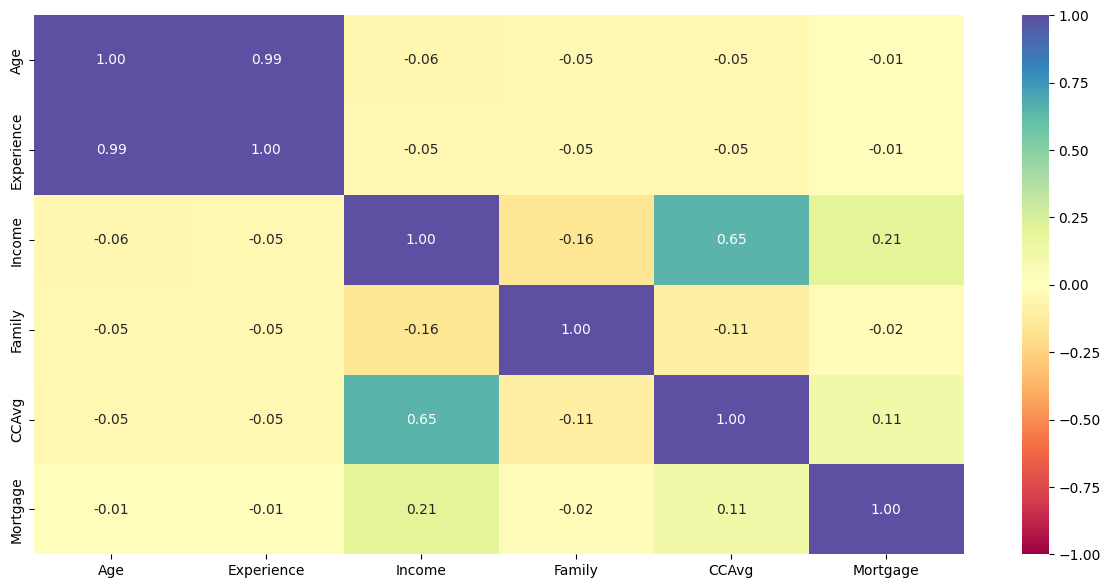

In [53]:
plt.figure(figsize=(15, 7))
sns.heatmap(df.corr(numeric_only=True), annot=True, vmin=-1, vmax=1, fmt=".2f", cmap="Spectral")
plt.show()

* Age and Experience have an almost perfect positive correlation, indicating strong dependency.
* Annual Income and Credit Card expenditure are moderated positive correlated (0.65).
* CCAvg and Income have a light negative correlation with Family, indicating both decrease slightly when family group increase.
* Income and CCAvg have a light positive correlation with Mortgage, indicating both increase slightly when mortgage increase. 

#### Let's check how a customer's interest in purchasing a loan varies with their education

Personal_Loan     0    1   All
Education                     
All            4520  480  5000
3              1296  205  1501
2              1221  182  1403
1              2003   93  2096
------------------------------------------------------------------------------------------------------------------------


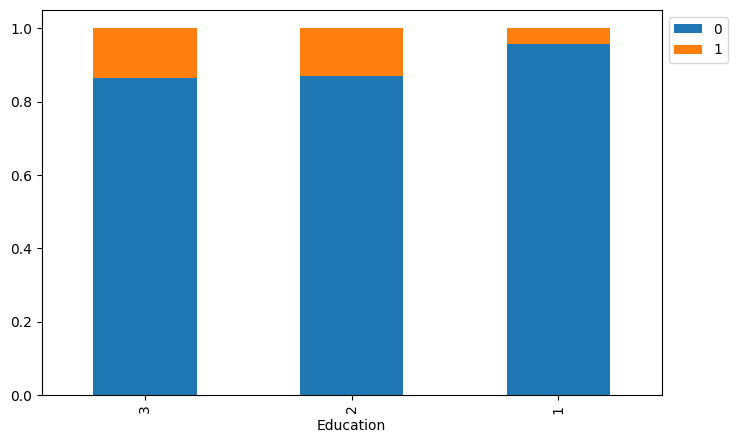

In [54]:
stacked_barplot(df, "Education", "Personal_Loan");   # Question 5

* Professionals (3) and Graduates (2) are more likely to purchase a loan.

#### Personal_Loan vs Family

Personal_Loan     0    1   All
Family                        
All            4520  480  5000
4              1088  134  1222
3               877  133  1010
1              1365  107  1472
2              1190  106  1296
------------------------------------------------------------------------------------------------------------------------


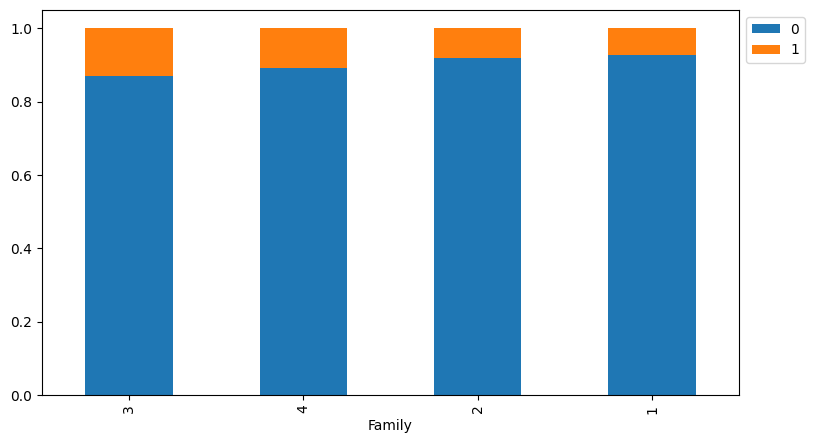

In [55]:
stacked_barplot(df, "Family", "Personal_Loan")

* Bigger families are more likely to purchase a loan.

#### Personal_Loan vs Securities_Account

Personal_Loan          0    1   All
Securities_Account                 
All                 4520  480  5000
0                   4058  420  4478
1                    462   60   522
------------------------------------------------------------------------------------------------------------------------


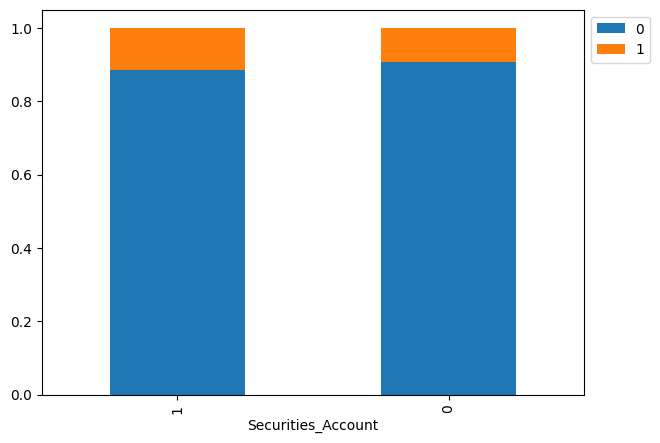

In [56]:
stacked_barplot(df, "Securities_Account", "Personal_Loan")

* People with securities account are more likely to purchase a loan.

#### Personal_Loan vs CD_Account

Personal_Loan     0    1   All
CD_Account                    
All            4520  480  5000
0              4358  340  4698
1               162  140   302
------------------------------------------------------------------------------------------------------------------------


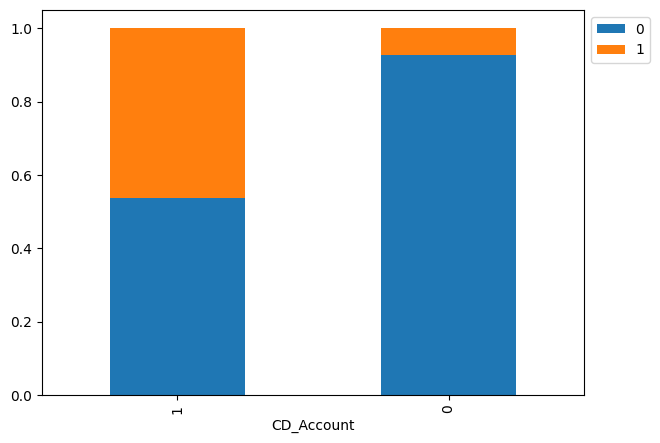

In [57]:
stacked_barplot(df, "CD_Account", "Personal_Loan")

* Customers with Certificates of Deposite are very much likely to purchase a loan.

#### Personal_Loan vs Online

Personal_Loan     0    1   All
Online                        
All            4520  480  5000
1              2693  291  2984
0              1827  189  2016


------------------------------------------------------------------------------------------------------------------------


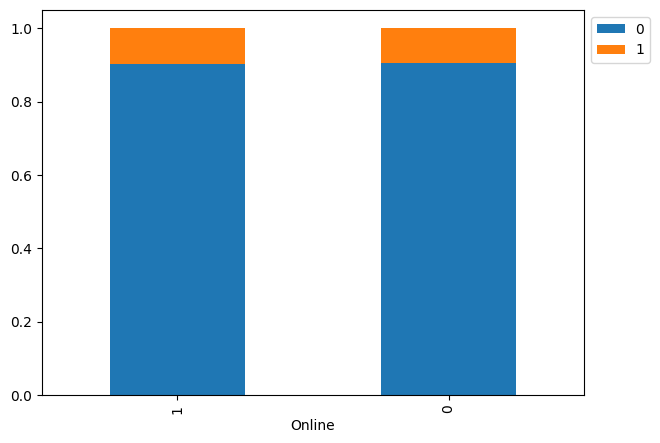

In [58]:
stacked_barplot(df, "Online", "Personal_Loan")

* There is almost no difference for customers online or not, to purchase a loan.

#### Personal_Loan vs CreditCard

Personal_Loan     0    1   All
CreditCard                    
All            4520  480  5000
0              3193  337  3530
1              1327  143  1470
------------------------------------------------------------------------------------------------------------------------


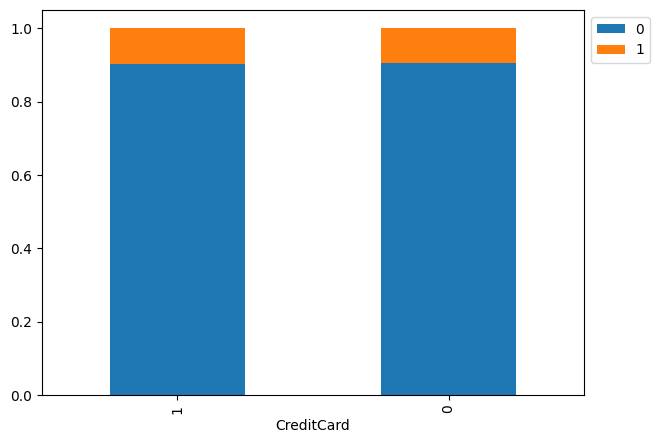

In [59]:
stacked_barplot(df, "CreditCard", "Personal_Loan")

* There is almost no difference for customers with credit card or not, to purchase a loan.

#### Personal_Loan vs Zone

Personal_Loan     0    1   All
Zone                          
All            4520  480  5000
Zone_5         1334  138  1472
Zone_3          894   94   988
Zone_6          735   80   815
Zone_1          636   67   703
Zone_2          510   55   565
Zone_4          374   43   417
Zone_0           37    3    40


------------------------------------------------------------------------------------------------------------------------


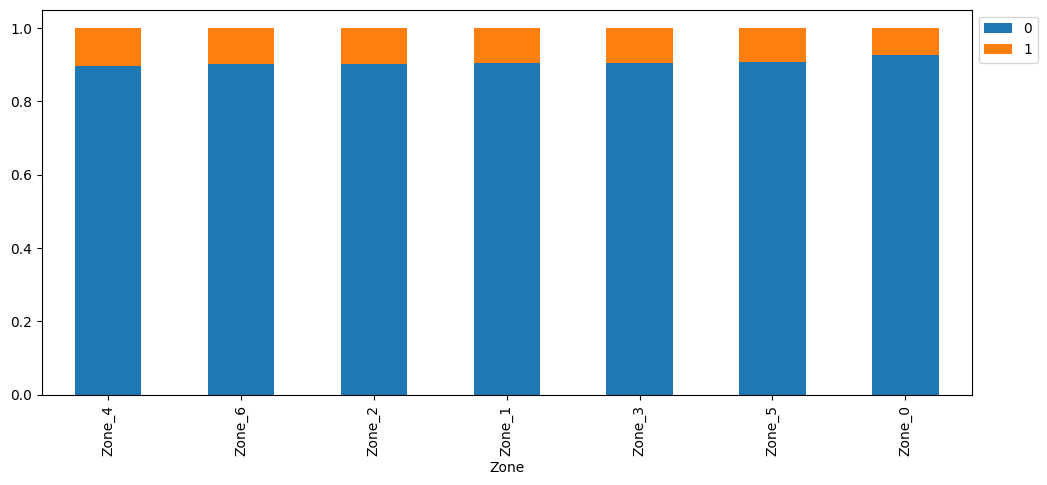

In [60]:
stacked_barplot(df, "Zone", "Personal_Loan")

* There is almost no difference for customers in the different zones, to purchase a loan. Just in Zone_0 is a visible lesser intent of purchasing.

#### Let's check how a customer's interest in purchasing a loan varies with their age

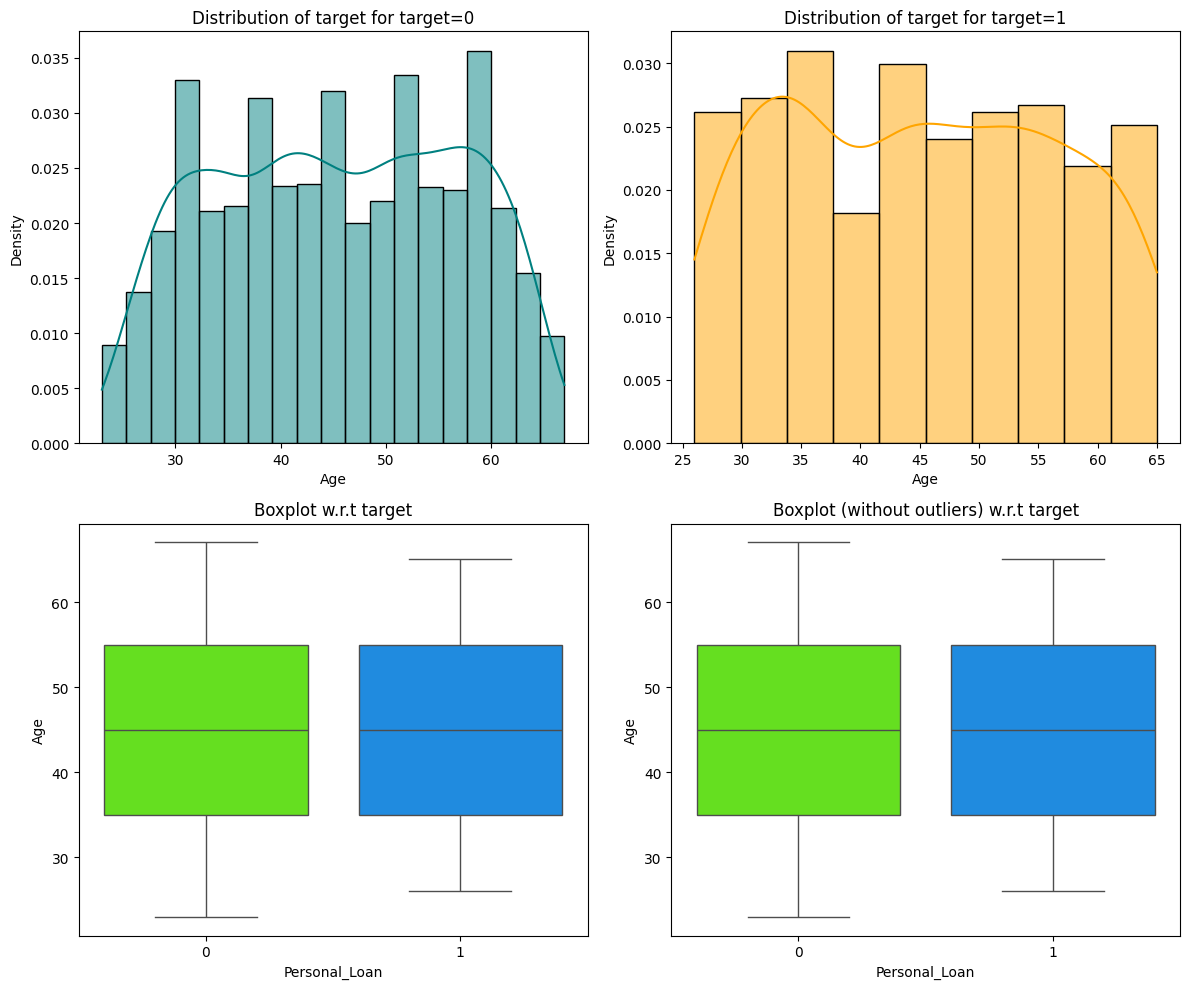

In [61]:
distribution_plot_wrt_target(df, "Age", "Personal_Loan")  # Question 4

* There seems to be no difference in the intent of purchasing a loan due to age.

#### Personal_Loan vs Experience

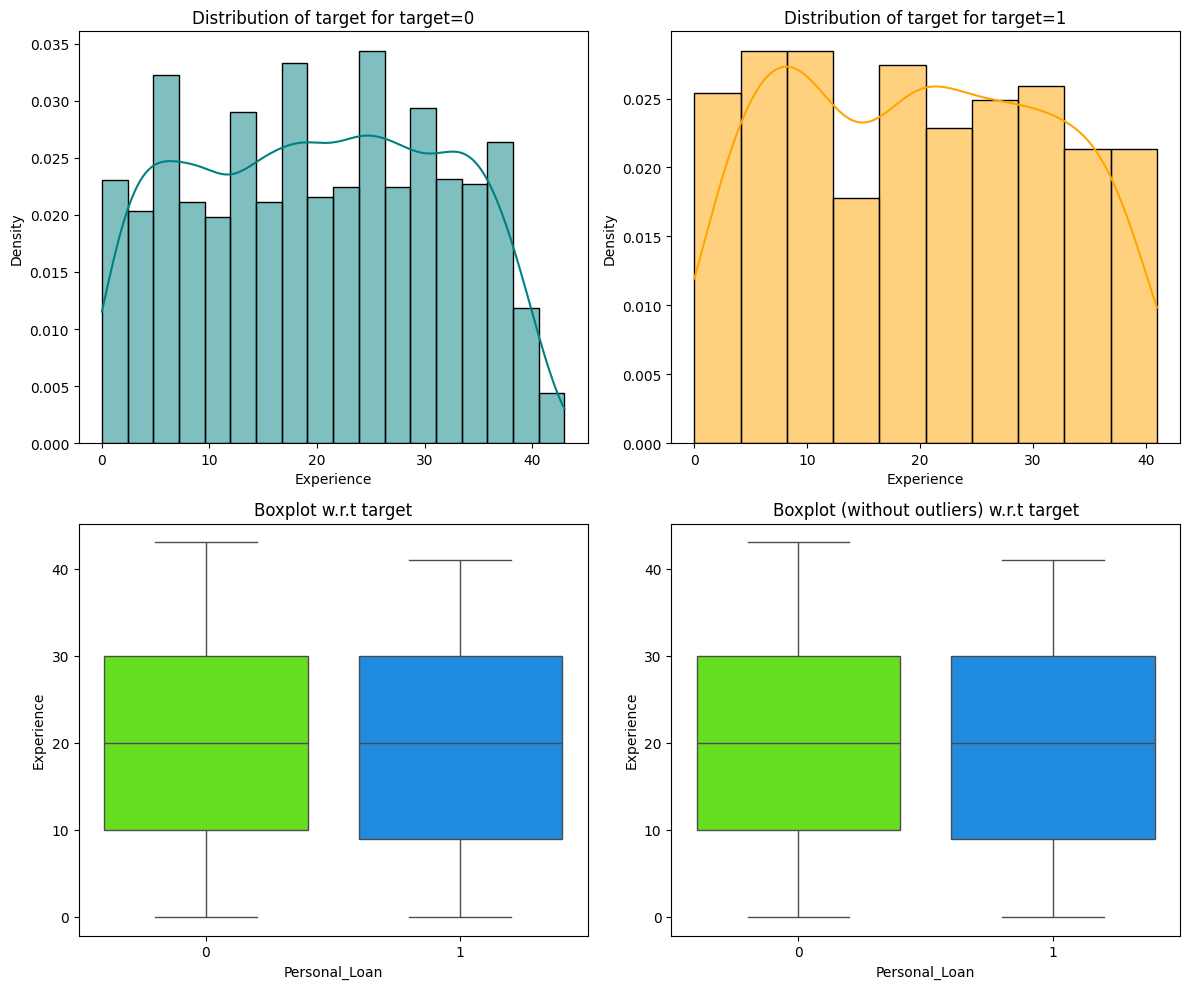

In [62]:
distribution_plot_wrt_target(df, "Experience", "Personal_Loan")

* There seems to be no difference in the intent of purchasing a loan due to experience.

#### Personal_Loan vs Income

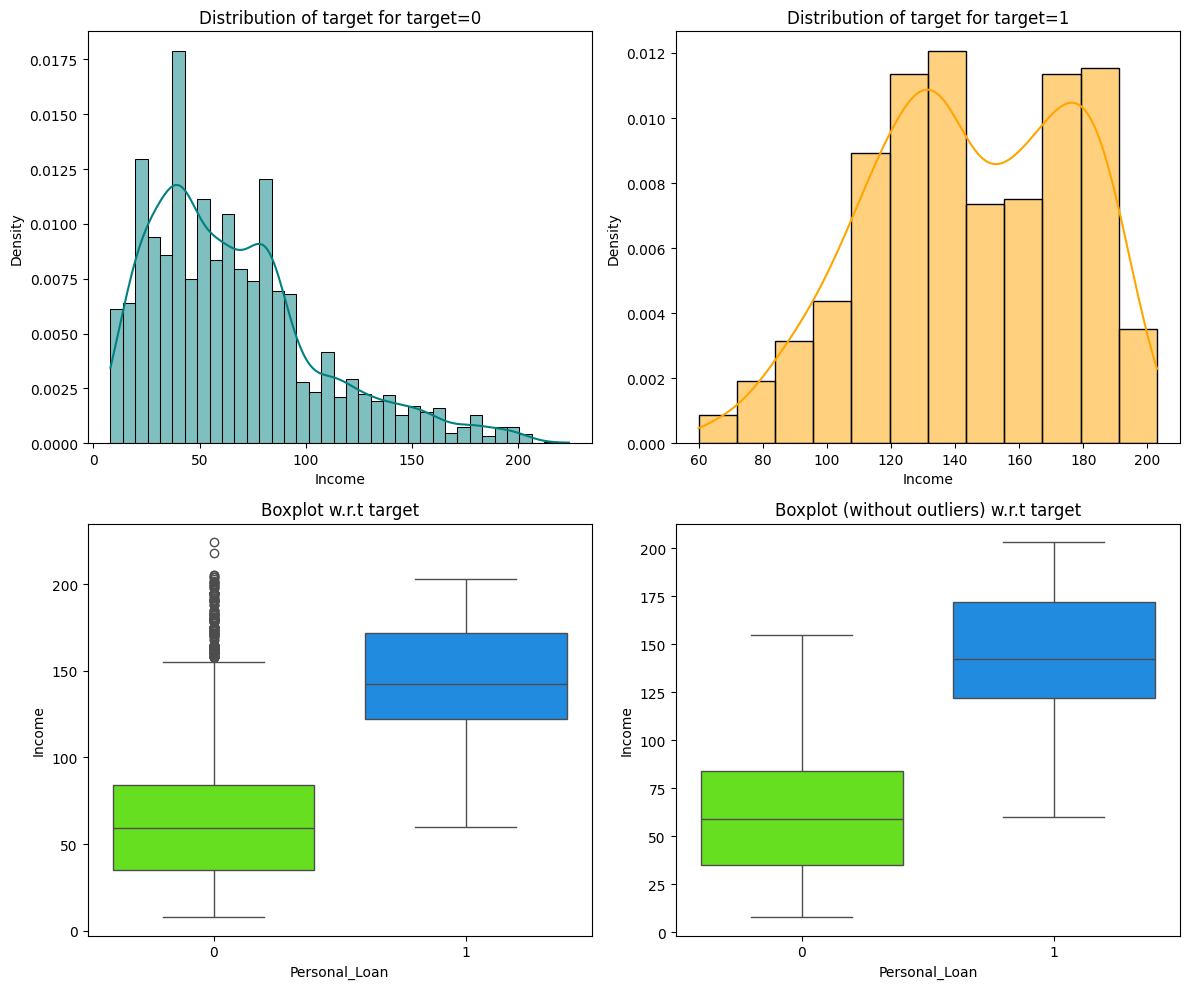

In [63]:
distribution_plot_wrt_target(df, "Income", "Personal_Loan")

* As Income increases, there is more likely to purchase a loan.

* Most Income outliers are related to 'No Loan', so it would benefit the model to adjust these values.

#### Personal_Loan vs CCAvg

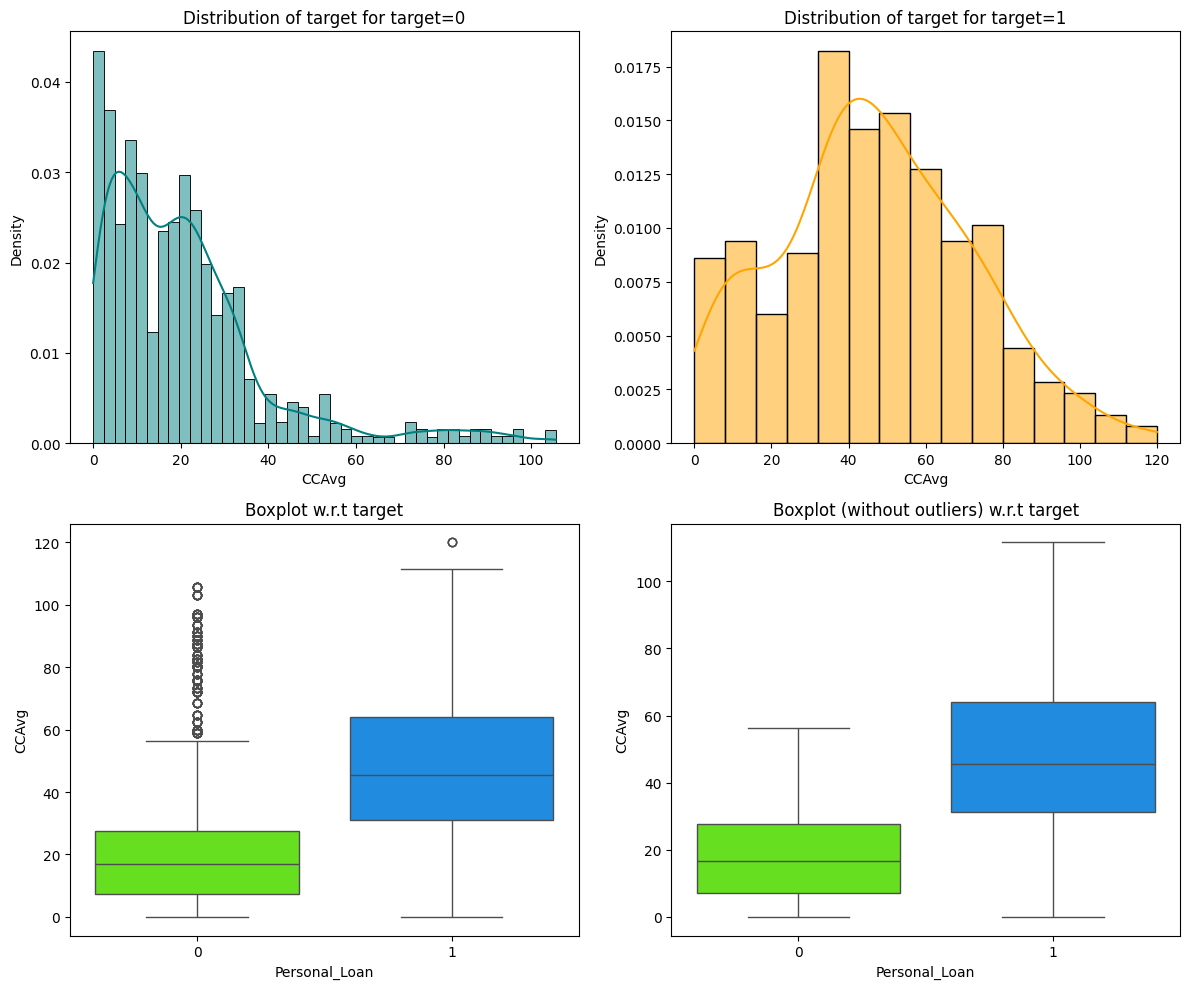

In [64]:
distribution_plot_wrt_target(df, "CCAvg", "Personal_Loan")

* As CCAvg increases, there is more likely to purchase a loan.

* Most CCAvg outliers are related to 'No Loan', so it would benefit the model to adjust these values.

#### Personal_Loan vs Mortgage

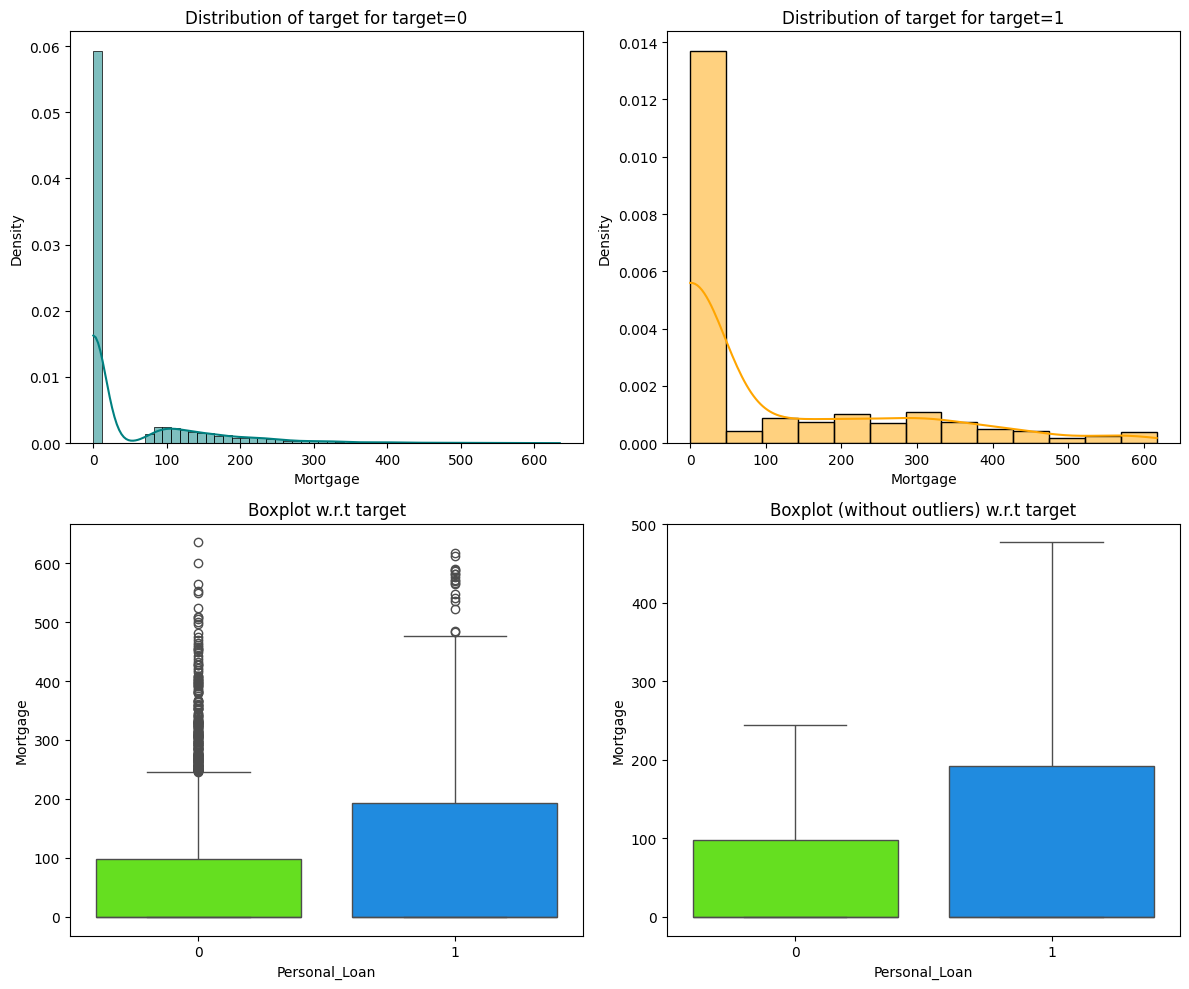

In [65]:
distribution_plot_wrt_target(df, "Mortgage", "Personal_Loan")

* As Mortgage increases, is likely to purchase a loan, but is not as clear as with Income or CCAvg.

* Most Mortgage outliers are related to 'No Loan', so it would benefit the model to adjust these values.

#### Income, CCAvg and CD_Account vs Personal_Loan

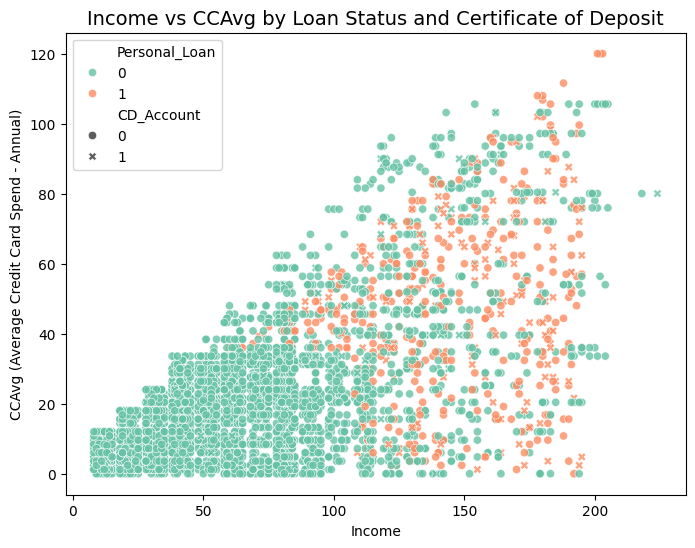

In [66]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x='Income', y='CCAvg', hue='Personal_Loan', style='CD_Account', palette='Set2', alpha=0.8);
plt.title('Income vs CCAvg by Loan Status and Certificate of Deposit', fontsize=14)
plt.xlabel('Income')
plt.ylabel('CCAvg (Average Credit Card Spend - Annual)');

* Below an Income of around 75 there are almost no personal loans. For greater Income there are more personal loans.

* In CCAvg, from 10 to around 80, most of the personal loans also have a Certificate of Deposit Account.

## Data Preprocessing

* Missing value treatment
* Feature engineering (if needed)
* Outlier detection and treatment (if needed)
* Preparing data for modeling
* Any other preprocessing steps (if needed)

### Outlier Detection

In [67]:
Q1 = df.select_dtypes(include=["float64", "int64"]).quantile(0.25)  # To find the 25th percentile and 75th percentile.
Q3 = df.select_dtypes(include=["float64", "int64"]).quantile(0.75)

IQR = Q3 - Q1  # Inter Quantile Range (75th perentile - 25th percentile)

lower = (
    Q1 - 1.5 * IQR
)  # Finding lower and upper bounds for all values. All values outside these bounds are outliers
upper = Q3 + 1.5 * IQR

In [68]:
(
    (df.select_dtypes(include=["float64", "int64"]) < lower)
    | (df.select_dtypes(include=["float64", "int64"]) > upper)
).sum() / len(df) * 100

Age           0.00
Experience    0.00
Income        1.92
Family        0.00
CCAvg         6.48
Mortgage      5.82
dtype: float64

In [69]:
# Columns that need outlier treatment
cols_with_outliers = ['Income', 'CCAvg', 'Mortgage']

for col in cols_with_outliers:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    # Cap outliers
    df[col] = np.where(df[col] < lower_limit, lower_limit,
                         np.where(df[col] > upper_limit, upper_limit, df[col]))

    


### Data Preparation for Modeling

In [70]:
# dropping Experience as it is perfectly correlated with Age
X = df.drop(["Personal_Loan", "Experience"], axis=1)
Y = df["Personal_Loan"]

X = pd.get_dummies(X, columns=["Zone", "Education"], drop_first=True)

X = X.astype(float)

# Splitting data in train and test sets 70 / 30
X_train, X_test, y_train, y_test = train_test_split(
    X, Y, test_size=0.30, random_state=20, stratify=Y
)

In [71]:
print("Shape of Training set : ", X_train.shape)
print("Shape of test set : ", X_test.shape)
print("Percentage of classes in training set:")
print(y_train.value_counts(normalize=True))
print("Percentage of classes in test set:")
print(y_test.value_counts(normalize=True))

Shape of Training set :  (3500, 17)
Shape of test set :  (1500, 17)
Percentage of classes in training set:
Personal_Loan
0    0.904
1    0.096
Name: proportion, dtype: float64
Percentage of classes in test set:
Personal_Loan
0    0.904
1    0.096
Name: proportion, dtype: float64


## Model Building

### Model Evaluation Criterion

**Model Objective:**
*  To predict whether a liability customer will buy personal loan, 
*  To understand which customer attributes are most significant in driving purchases, and 
*  Identify which segment of customers to target more.

**Model's possible wrong predictions (confusion matrix):**
*  Predicts Customer will not take a loan, but in reality, Customer actually takes a loan (FN)
*  Predicts Customer will take a loan, but in reality, Customer actually does not take a loan (FP)

**Impact of wrong predictions:**

*  For False Negatives (FN) — The bank may loose a potential business opportunity (missed revenue, lower marketing efficiency).

*  For False Positives (FP) — The bank may incur a minor costs (extra marketing, time).

*  False Negatives (FN) are more costly than False Positives (FP).

**Model Focus:**

*  Maximize Recall (Sensitivity) but if possible try to reduce extra costs (keep a good F1 Score).

*  High Recall will move FN to TP, ensuring fewer missed potential customers.

**General Model:**

*  For this project *Decision Tree* model will be used.



### Model Building

First, let's create functions to calculate different metrics and confusion matrix so that we don't have to use the same code repeatedly for each model.

* The model_performance_classification function will be used to check the model performance of models.
* The plot_confusion_matrix function will be used to plot confusion matrix.

In [72]:
# defining a function to compute different metrics to check performance of a classification model built using sklearn
def model_performance_classification(model, predictors, target):
    """
    Function to compute different metrics to check classification model performance

    model: classifier
    predictors: independent variables
    target: dependent variable
    """

    # predicting using the independent variables
    pred = model.predict(predictors)

    acc = accuracy_score(target, pred)  # to compute Accuracy
    recall = recall_score(target, pred)  # to compute Recall
    precision = precision_score(target, pred)  # to compute Precision
    f1 = f1_score(target, pred)  # to compute F1-score

    # creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {"Accuracy": acc, "Recall": recall, "Precision": precision, "F1": f1,},
        index=[0],
    )

    return df_perf

In [73]:
def plot_confusion_matrix(model, predictors, target):
    """
    To plot the confusion_matrix with percentages

    model: classifier
    predictors: independent variables
    target: dependent variable
    """
    # Predict the target values using the provided model and predictors
    y_pred = model.predict(predictors)

    # Compute the confusion matrix comparing the true target values with the predicted values
    cm = confusion_matrix(target, y_pred)

    # Create labels for each cell in the confusion matrix with both count and percentage
    labels = np.asarray(
        [
            ["{0:0.0f}".format(item) + "\n{0:.2%}".format(item / cm.flatten().sum())]
            for item in cm.flatten()
        ]
    ).reshape(2, 2)    # reshaping to a matrix

    # Set the figure size for the plot
    plt.figure(figsize=(6, 4))

    # Plot the confusion matrix as a heatmap with the labels
    sns.heatmap(cm, annot=labels, fmt="")

    # Add a label to the y-axis
    plt.ylabel("True label")

    # Add a label to the x-axis
    plt.xlabel("Predicted label")

### Decision Tree (sklearn default)

In [74]:
# creating an instance of the decision tree model
model = DecisionTreeClassifier(random_state=20)    # random_state sets a seed value and enables reproducibility

# fitting the model to the training data
model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,20
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


#### Checking model performance on training data

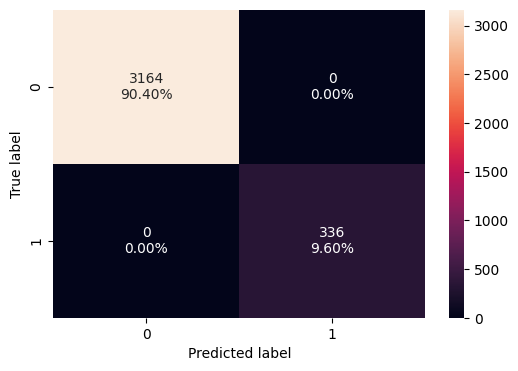

In [75]:
plot_confusion_matrix(model, X_train, y_train)

In [76]:
decision_tree_perf_train = model_performance_classification(
    model, X_train, y_train
)
decision_tree_perf_train

,Accuracy,Recall,Precision,F1
0,1.0,1.0,1.0,1.0


#### Visualizing the Decision Tree

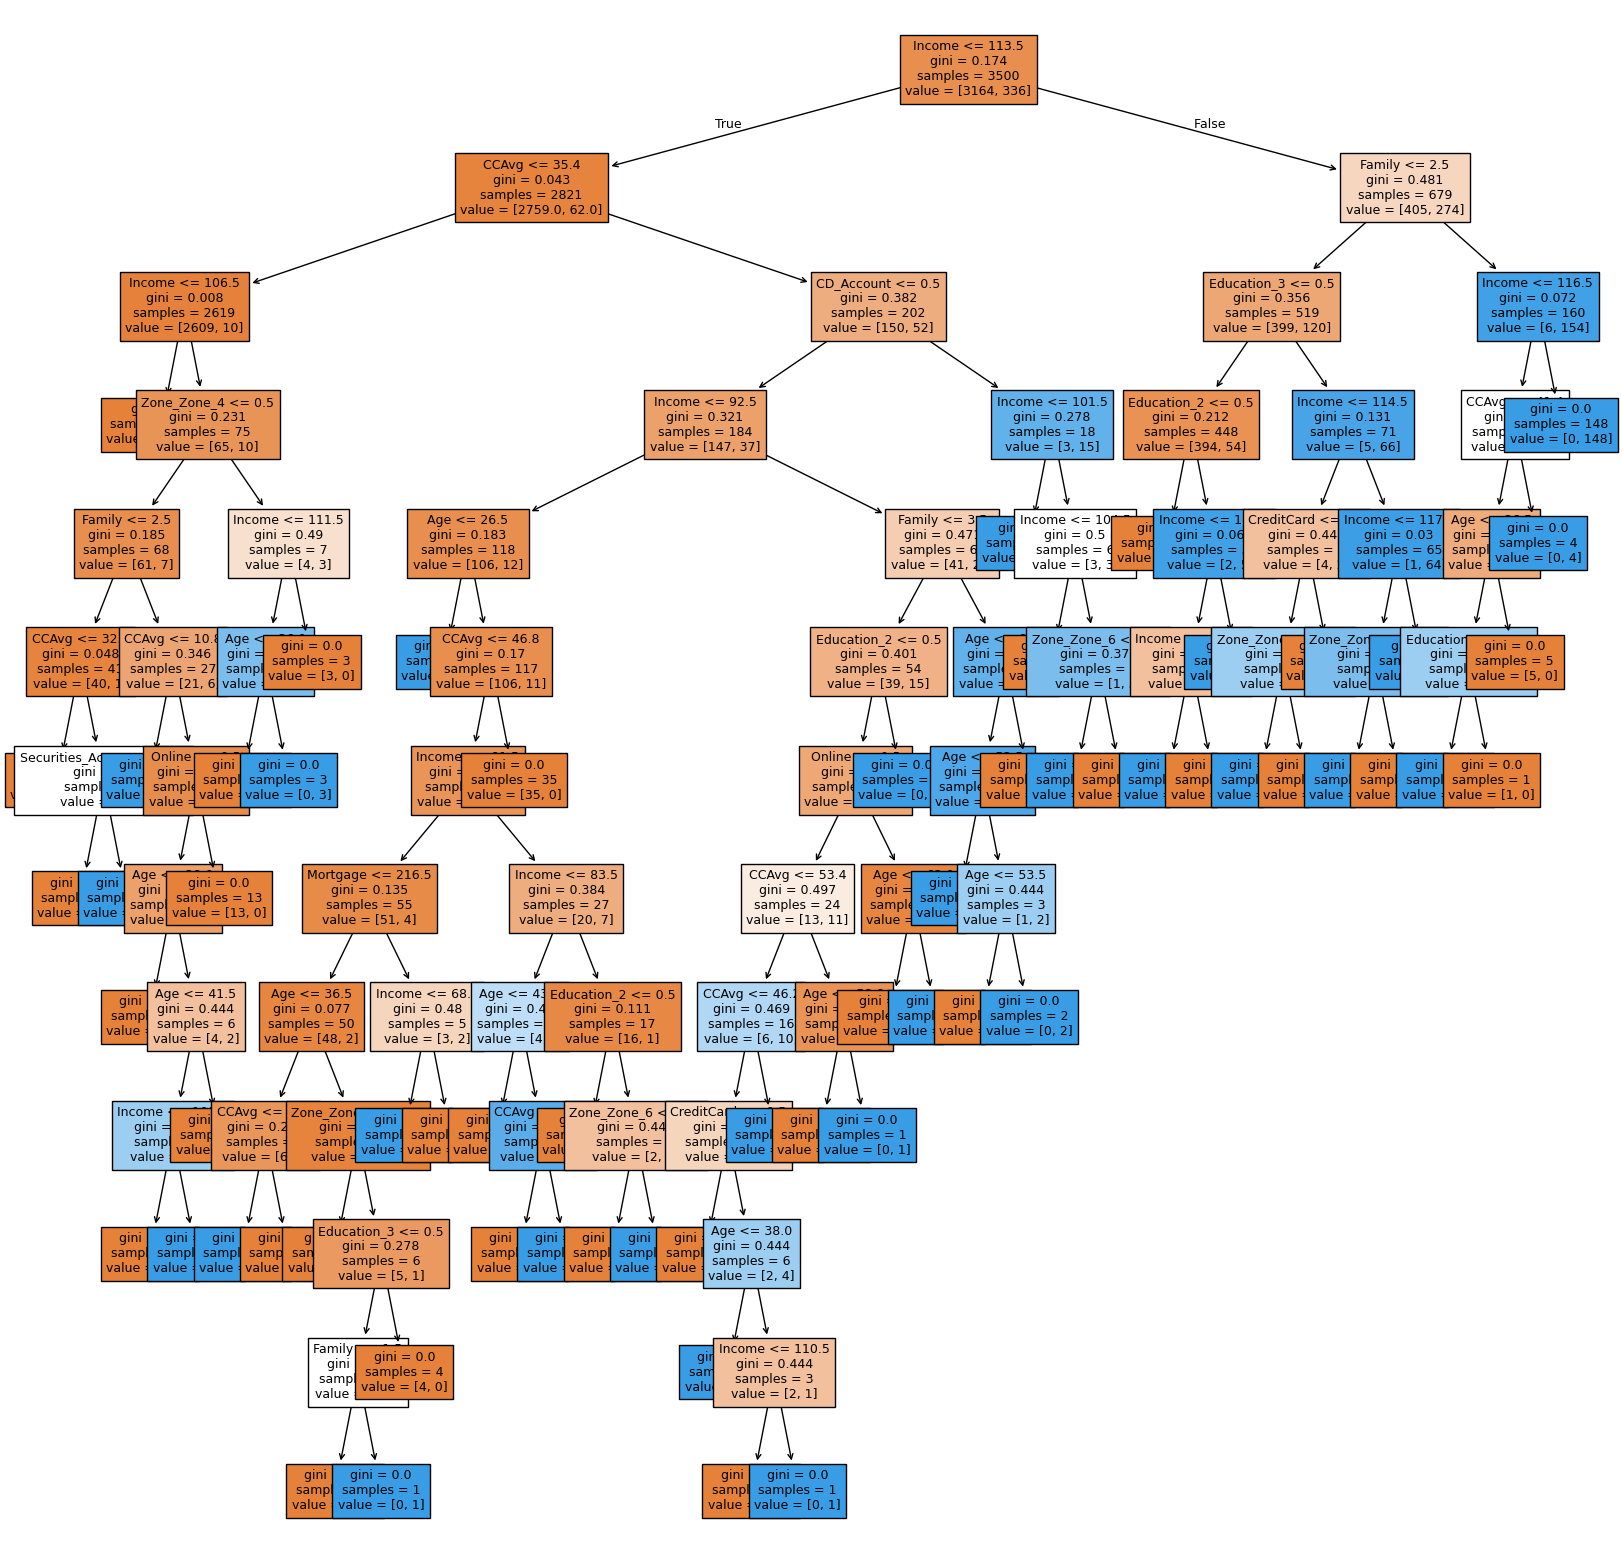

In [77]:
# list of feature names in X_train
feature_names = list(X_train.columns)

# set the figure size for the plot
plt.figure(figsize=(20, 20))

# plotting the decision tree
out = tree.plot_tree(
    model,                         # decision tree classifier model
    feature_names=feature_names,    # list of feature names (columns) in the dataset
    filled=True,                    # fill the nodes with colors based on class
    fontsize=9,                     # font size for the node text
    node_ids=False,                 # do not show the ID of each node
    class_names=None,               # whether or not to display class names
)

# add arrows to the decision tree splits if they are missing
for o in out:
    arrow = o.arrow_patch
    if arrow is not None:
        arrow.set_edgecolor("black")    # set arrow color to black
        arrow.set_linewidth(1)          # set arrow linewidth to 1

# displaying the plot
plt.show()

In [78]:
# printing a text report showing the rules of a decision tree
print(
    tree.export_text(
        model,    # specify the model
        feature_names=feature_names,    # specify the feature names
        show_weights=True    # specify whether or not to show the weights associated with the model
    )
)

|--- Income <= 113.50
|   |--- CCAvg <= 35.40
|   |   |--- Income <= 106.50
|   |   |   |--- weights: [2544.00, 0.00] class: 0
|   |   |--- Income >  106.50
|   |   |   |--- Zone_Zone_4 <= 0.50
|   |   |   |   |--- Family <= 2.50
|   |   |   |   |   |--- CCAvg <= 32.70
|   |   |   |   |   |   |--- weights: [39.00, 0.00] class: 0
|   |   |   |   |   |--- CCAvg >  32.70
|   |   |   |   |   |   |--- Securities_Account <= 0.50
|   |   |   |   |   |   |   |--- weights: [1.00, 0.00] class: 0
|   |   |   |   |   |   |--- Securities_Account >  0.50
|   |   |   |   |   |   |   |--- weights: [0.00, 1.00] class: 1
|   |   |   |   |--- Family >  2.50
|   |   |   |   |   |--- CCAvg <= 10.80
|   |   |   |   |   |   |--- weights: [0.00, 4.00] class: 1
|   |   |   |   |   |--- CCAvg >  10.80
|   |   |   |   |   |   |--- Online <= 0.50
|   |   |   |   |   |   |   |--- Age <= 28.00
|   |   |   |   |   |   |   |   |--- weights: [4.00, 0.00] class: 0
|   |   |   |   |   |   |   |--- Age >  28.00
|   |   |

In [79]:
# importance of features in the tree building ( The importance of a feature is computed as the
# (normalized) total reduction of the criterion brought by that feature. It is also known as the Gini importance )

print(
    pd.DataFrame(
        model.feature_importances_, columns=["Imp"], index=X_train.columns
    ).sort_values(by="Imp", ascending=False)
)

                         Imp
Income              0.326624
Family              0.229040
Education_2         0.156362
Education_3         0.135362
CCAvg               0.071497
Age                 0.030061
CD_Account          0.021578
Online              0.008169
CreditCard          0.005707
Zone_Zone_6         0.004664
Zone_Zone_4         0.004410
Zone_Zone_2         0.002941
Mortgage            0.001939
Securities_Account  0.001646
Zone_Zone_3         0.000000
Zone_Zone_5         0.000000
Zone_Zone_0         0.000000


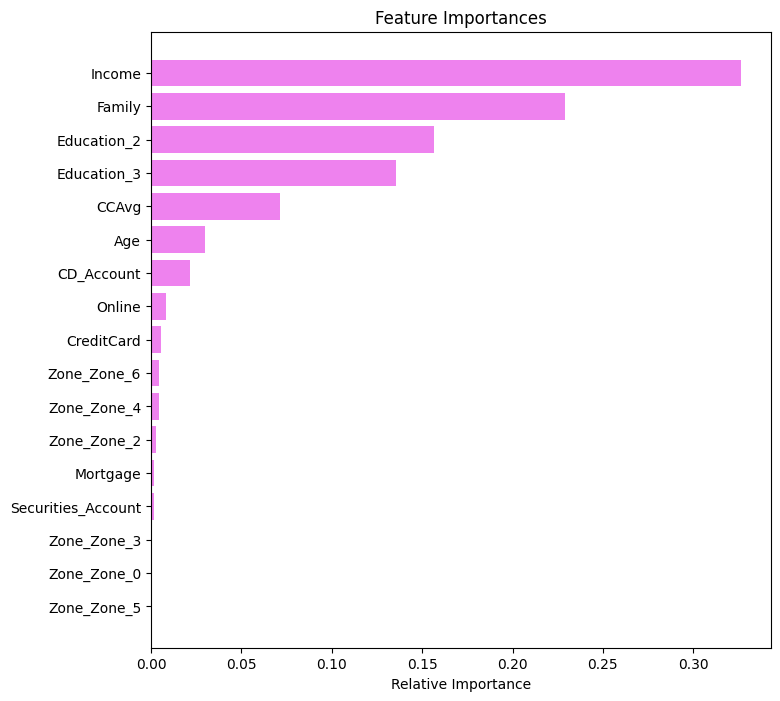

In [80]:
importances = model.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(8, 8))
plt.title("Feature Importances")
plt.barh(range(len(indices)), importances[indices], color="violet", align="center")
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel("Relative Importance")
plt.show()

#### Checking model performance on test data

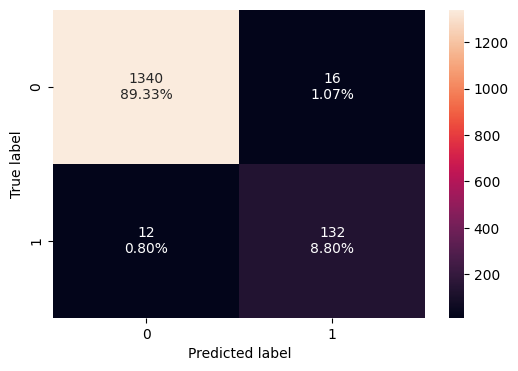

In [81]:
plot_confusion_matrix(model, X_test, y_test)

In [82]:
decision_tree_perf_test = model_performance_classification(model, X_test, y_test)
decision_tree_perf_test

,Accuracy,Recall,Precision,F1
0,0.981333,0.916667,0.891892,0.90411


### Decision Tree (with class_weights)

* From the EDA there was detected a class imbalance, so class_weight = "balanced" will be used to automatically adjust the weights to be inversely proportional to the class frequencies in the input data.

In [83]:
model1 = DecisionTreeClassifier(random_state=20, class_weight="balanced")
model1.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,20
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,'balanced'


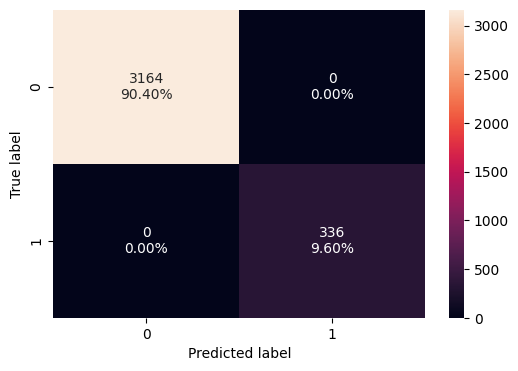

In [84]:
plot_confusion_matrix(model1, X_train, y_train)

In [85]:
decision_tree_bal_perf_train = model_performance_classification(
    model1, X_train, y_train
)
decision_tree_bal_perf_train

,Accuracy,Recall,Precision,F1
0,1.0,1.0,1.0,1.0


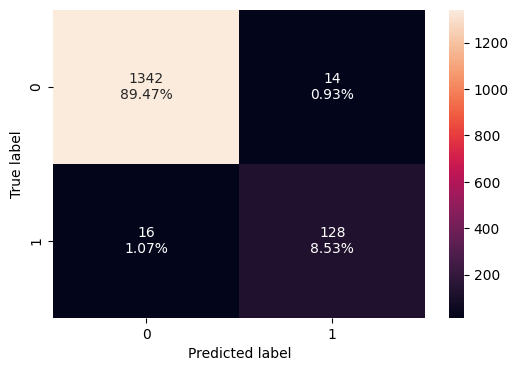

In [86]:
plot_confusion_matrix(model1, X_test, y_test)

In [87]:
decision_tree_bal_perf_test = model_performance_classification(
    model1, X_test, y_test
)
decision_tree_bal_perf_test

,Accuracy,Recall,Precision,F1
0,0.98,0.888889,0.901408,0.895105


## Model Performance Improvement

#### Pre-pruning

In [88]:
# define the parameters of the tree to iterate over
max_depth_values = np.arange(2, 11, 1)
max_leaf_nodes_values = np.arange(10, 151, 10)
min_samples_split_values = np.arange(10, 71, 10)

# initialize variables to store the best model and its performance
best_estimator = None
best_score_diff = float('inf')
best_test_score = 0.0

# iterate over all combinations of the specified parameter values
for max_depth in max_depth_values:
    for max_leaf_nodes in max_leaf_nodes_values:
        for min_samples_split in min_samples_split_values:

            # initialize the tree with the current set of parameters
            estimator = DecisionTreeClassifier(
                max_depth=max_depth,
                max_leaf_nodes=max_leaf_nodes,
                min_samples_split=min_samples_split,
                class_weight='balanced',
                random_state=20
            )

            # Fit the model to the training data
            estimator.fit(X_train, y_train)

            # Make predictions on the training and test sets
            y_train_pred = estimator.predict(X_train)
            y_test_pred = estimator.predict(X_test)

            # Calculate recall scores for training and test sets
            train_recall_score = recall_score(y_train, y_train_pred)
            test_recall_score = recall_score(y_test, y_test_pred)

            # Calculate the absolute difference between training and test recall scores
            score_diff = abs(train_recall_score - test_recall_score)

            # Update the best estimator and best score if the current one has a smaller score difference
            if (score_diff < best_score_diff) & (test_recall_score > best_test_score):
                best_score_diff = score_diff
                best_test_score = test_recall_score
                best_estimator = estimator

# Print the best parameters
print("Best parameters found:")
print(f"Max depth: {best_estimator.max_depth}")
print(f"Max leaf nodes: {best_estimator.max_leaf_nodes}")
print(f"Min samples split: {best_estimator.min_samples_split}")
print(f"Best test recall score: {best_test_score}")

Best parameters found:
Max depth: 2
Max leaf nodes: 10
Min samples split: 10
Best test recall score: 1.0


In [89]:
# creating an instance of the best model
model2 = best_estimator

# fitting the best model to the training data
model2.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,np.int64(2)
,min_samples_split,np.int64(10)
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,20
,max_leaf_nodes,np.int64(10)
,min_impurity_decrease,0.0
,class_weight,'balanced'


**Checking performance on training data**

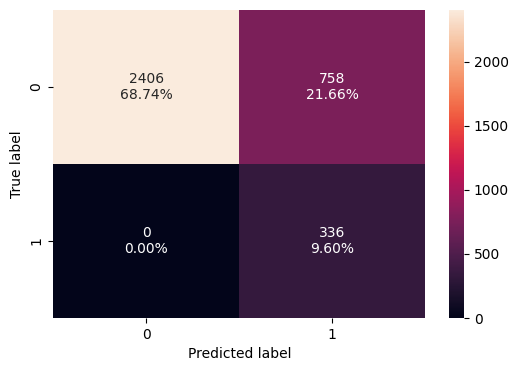

In [90]:
plot_confusion_matrix(model2, X_train, y_train)

In [91]:
decision_tree_tune_perf_train = model_performance_classification(model2, X_train, y_train)
decision_tree_tune_perf_train

,Accuracy,Recall,Precision,F1
0,0.783429,1.0,0.30713,0.46993


**Visualizing the Decision Tree**

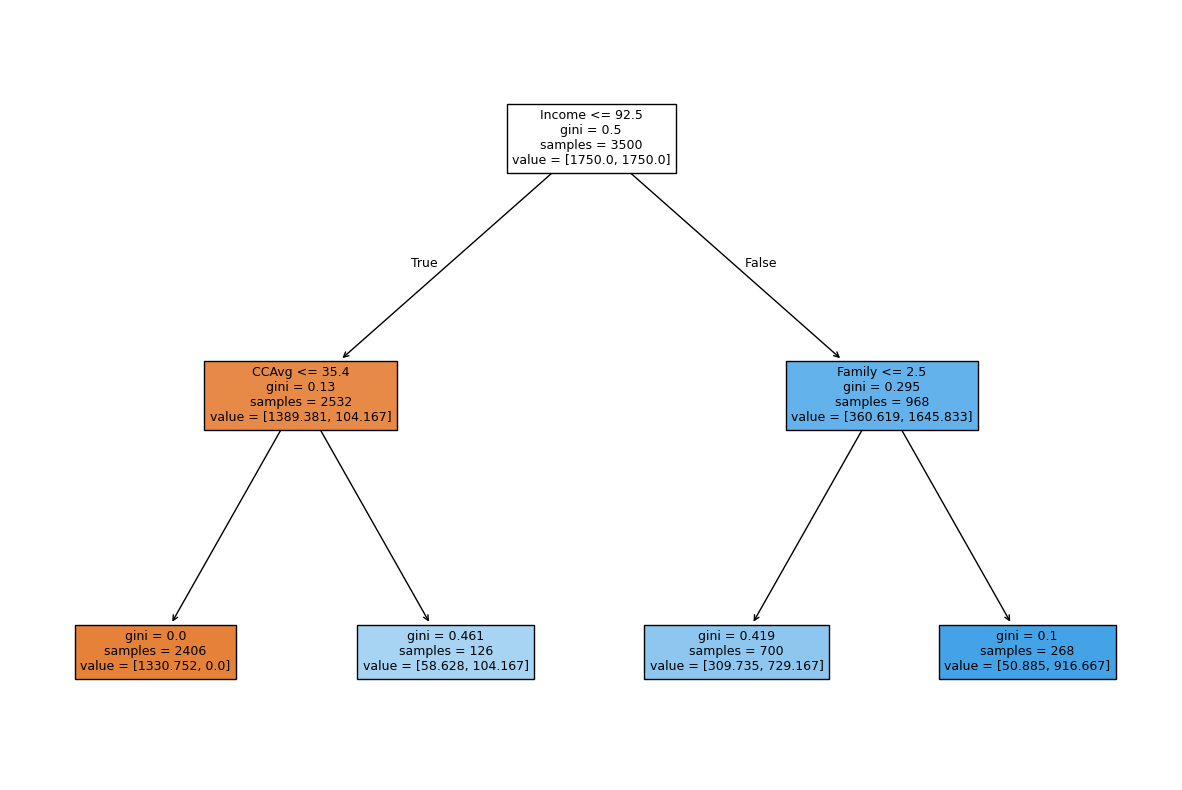

In [92]:
# list of feature names in X_train
feature_names = list(X_train.columns)

# set the figure size for the plot
plt.figure(figsize=(15, 10))

# plotting the decision tree
out = tree.plot_tree(
    model2,                         # decision tree classifier model
    feature_names=feature_names,    # list of feature names (columns) in the dataset
    filled=True,                    # fill the nodes with colors based on class
    fontsize=9,                     # font size for the node text
    node_ids=False,                 # do not show the ID of each node
    class_names=None,               # whether or not to display class names
)

# add arrows to the decision tree splits if they are missing
for o in out:
    arrow = o.arrow_patch
    if arrow is not None:
        arrow.set_edgecolor("black")    # set arrow color to black
        arrow.set_linewidth(1)          # set arrow linewidth to 1

# displaying the plot
plt.show()

In [93]:
# printing a text report showing the rules of a decision tree
print(
    tree.export_text(
        model2,    # specify the model
        feature_names=feature_names,    # specify the feature names
        show_weights=True    # specify whether or not to show the weights associated with the model
    )
)

|--- Income <= 92.50
|   |--- CCAvg <= 35.40
|   |   |--- weights: [1330.75, 0.00] class: 0
|   |--- CCAvg >  35.40
|   |   |--- weights: [58.63, 104.17] class: 1
|--- Income >  92.50
|   |--- Family <= 2.50
|   |   |--- weights: [309.73, 729.17] class: 1
|   |--- Family >  2.50
|   |   |--- weights: [50.88, 916.67] class: 1



In [94]:
# importance of features in the tree building ( The importance of a feature is computed as the
# (normalized) total reduction of the criterion brought by that feature. It is also known as the Gini importance )

print(
    pd.DataFrame(
        estimator.feature_importances_, columns=["Imp"], index=X_train.columns
    ).sort_values(by="Imp", ascending=False)
)

                             Imp
Income              6.374624e-01
Education_2         1.505725e-01
CCAvg               1.031845e-01
Education_3         5.254635e-02
Family              3.744953e-02
CD_Account          1.607465e-02
Age                 2.710117e-03
Zone_Zone_5         3.493386e-16
Mortgage            0.000000e+00
CreditCard          0.000000e+00
Online              0.000000e+00
Securities_Account  0.000000e+00
Zone_Zone_2         0.000000e+00
Zone_Zone_4         0.000000e+00
Zone_Zone_3         0.000000e+00
Zone_Zone_0         0.000000e+00
Zone_Zone_6         0.000000e+00


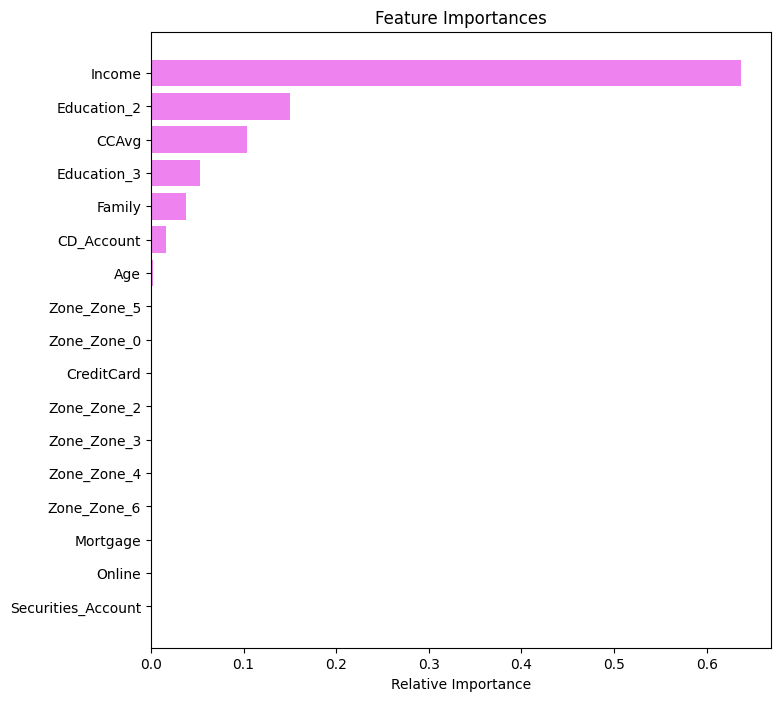

In [95]:
importances = estimator.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(8, 8))
plt.title("Feature Importances")
plt.barh(range(len(indices)), importances[indices], color="violet", align="center")
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel("Relative Importance")
plt.show()

**Checking performance on test data**

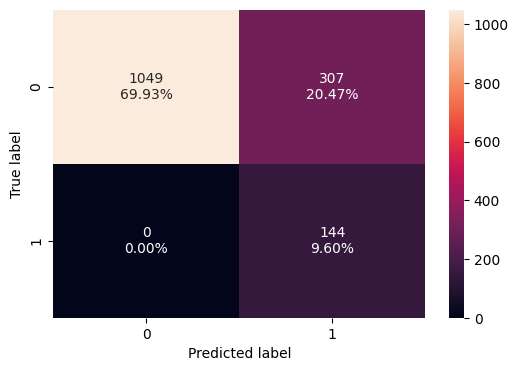

In [96]:
plot_confusion_matrix(model2, X_test, y_test)

In [97]:
decision_tree_tune_perf_test = model_performance_classification(model2, X_test, y_test)
decision_tree_tune_perf_test

,Accuracy,Recall,Precision,F1
0,0.795333,1.0,0.31929,0.484034


#### Post-pruning

In [98]:
# Create an instance of the decision tree model
clf = DecisionTreeClassifier(class_weight="balanced", random_state=20)

# Compute the cost complexity pruning path for the model using the training data
path = clf.cost_complexity_pruning_path(X_train, y_train)

# Extract the array of effective alphas from the pruning path
ccp_alphas = abs(path.ccp_alphas)

# Extract the array of total impurities at each alpha along the pruning path
impurities = path.impurities

In [99]:
pd.DataFrame(path)

,ccp_alphas,impurities
0,0.000000e+00,-1.129347e-16
1,1.052677e-19,-1.128294e-16
2,1.543926e-18,-1.112855e-16
3,1.543926e-18,-1.097415e-16
4,2.368523e-18,-1.073730e-16
5,2.478176e-18,-1.048948e-16
6,2.736959e-18,-1.021579e-16
7,4.052805e-18,-9.810508e-17
8,4.956353e-18,-9.314873e-17
9,5.087937e-18,-8.806079e-17


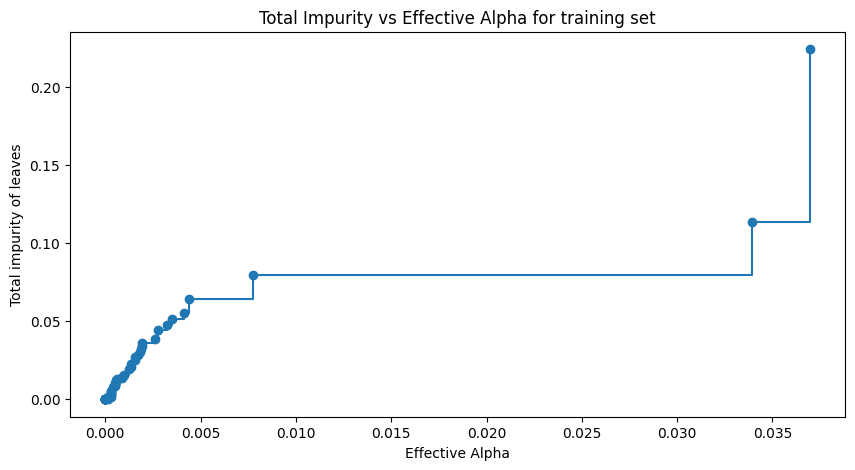

In [100]:
# Create a figure
fig, ax = plt.subplots(figsize=(10, 5))

# Plot the total impurities versus effective alphas, excluding the last value,
# using markers at each data point and connecting them with steps
ax.plot(ccp_alphas[:-1], impurities[:-1], marker="o", drawstyle="steps-post")

# Set the x-axis label
ax.set_xlabel("Effective Alpha")

# Set the y-axis label
ax.set_ylabel("Total impurity of leaves")

# Set the title of the plot
ax.set_title("Total Impurity vs Effective Alpha for training set");

Next, we train a decision tree using effective alphas. The last value
in ``ccp_alphas`` is the alpha value that prunes the whole tree,
leaving the tree, ``clfs[-1]``, with one node.

In [101]:
# Initialize an empty list to store the decision tree classifiers
clfs = []

# Iterate over each ccp_alpha value extracted from cost complexity pruning path
for ccp_alpha in ccp_alphas:
    # Create an instance of the DecisionTreeClassifier
    clf = DecisionTreeClassifier(ccp_alpha=ccp_alpha, class_weight="balanced", random_state=20)

    # Fit the classifier to the training data
    clf.fit(X_train, y_train)

    # Append the trained classifier to the list
    clfs.append(clf)

# Print the number of nodes in the last tree along with its ccp_alpha value
print(
    "Number of nodes in the last tree is {} with ccp_alpha {}".format(
        clfs[-1].tree_.node_count, ccp_alphas[-1]
    )
)

Number of nodes in the last tree is 1 with ccp_alpha 0.2755959990691343


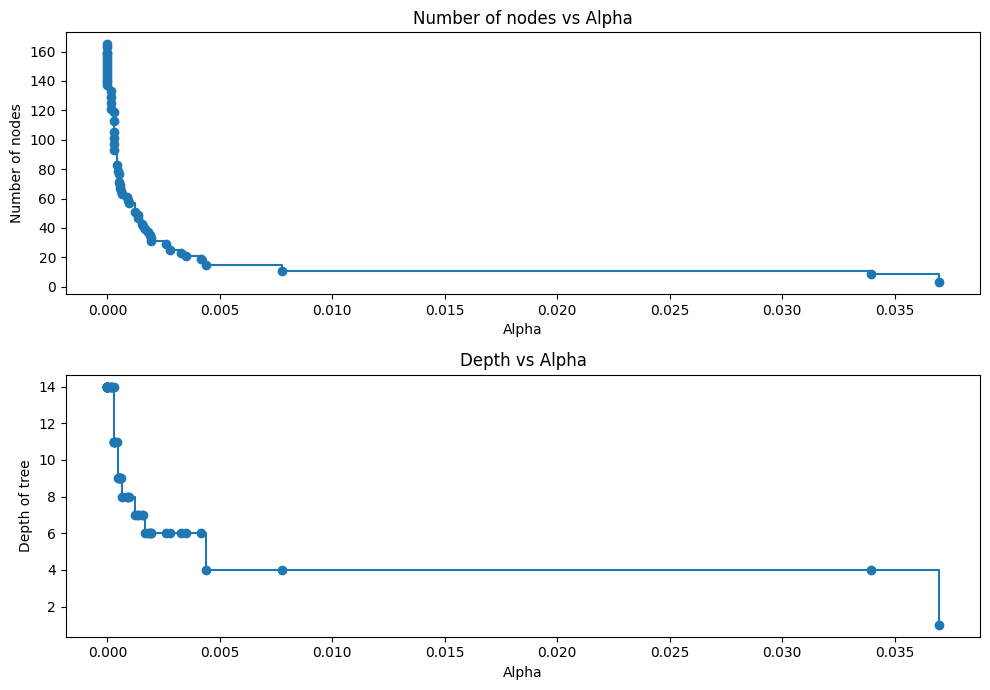

In [102]:
# Remove the last classifier and corresponding ccp_alpha value from the lists
clfs = clfs[:-1]
ccp_alphas = ccp_alphas[:-1]

# Extract the number of nodes in each tree classifier
node_counts = [clf.tree_.node_count for clf in clfs]

# Extract the maximum depth of each tree classifier
depth = [clf.tree_.max_depth for clf in clfs]

# Create a figure and a set of subplots
fig, ax = plt.subplots(2, 1, figsize=(10, 7))

# Plot the number of nodes versus ccp_alphas on the first subplot
ax[0].plot(ccp_alphas, node_counts, marker="o", drawstyle="steps-post")
ax[0].set_xlabel("Alpha")
ax[0].set_ylabel("Number of nodes")
ax[0].set_title("Number of nodes vs Alpha")

# Plot the depth of tree versus ccp_alphas on the second subplot
ax[1].plot(ccp_alphas, depth, marker="o", drawstyle="steps-post")
ax[1].set_xlabel("Alpha")
ax[1].set_ylabel("Depth of tree")
ax[1].set_title("Depth vs Alpha")

# Adjust the layout of the subplots to avoid overlap
fig.tight_layout()

In [103]:
train_recall_score = []  # Initialize an empty list to store Recall scores for training set for each decision tree classifier

# Iterate through each decision tree classifier in 'clfs'
for clf in clfs:
    # Predict labels for the training set using the current decision tree classifier
    pred_train = clf.predict(X_train)

    # Calculate the Recall score for the training set predictions compared to true labels
    values_train = recall_score(y_train, pred_train)

    # Append the calculated Recall score to the train_recall_score list
    train_recall_score.append(values_train)

test_recall_scores = []  # Initialize an empty list to store Recall scores for test set for each decision tree classifier

# Iterate through each decision tree classifier in 'clfs'
for clf in clfs:
    # Predict labels for the test set using the current decision tree classifier
    pred_test = clf.predict(X_test)

    # Calculate the Recall score for the test set predictions compared to true labels
    values_test = recall_score(y_test, pred_test)

    # Append the calculated Recall score to the test_recall_scores list
    test_recall_scores.append(values_test)

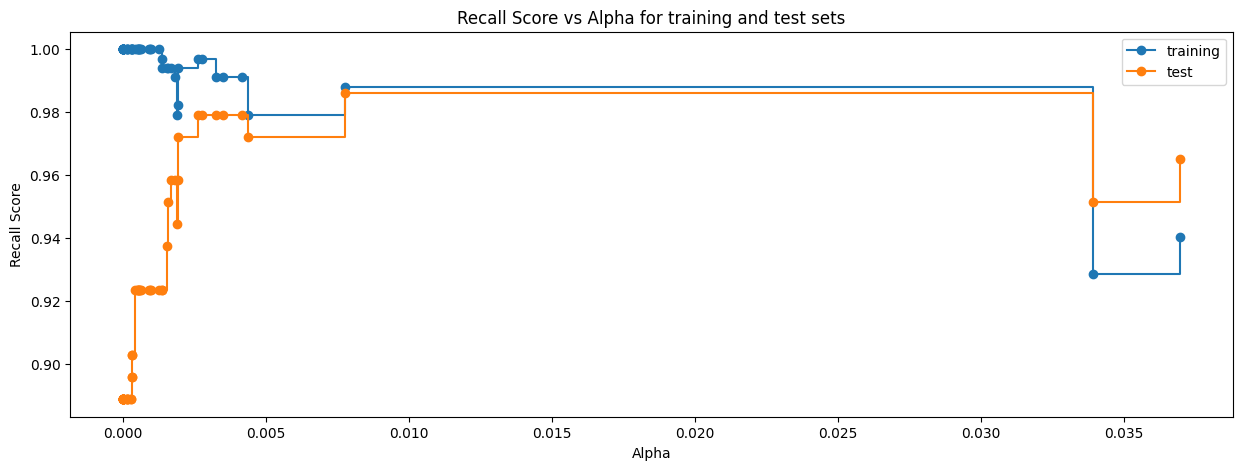

In [104]:
# Create a figure
fig, ax = plt.subplots(figsize=(15, 5))
ax.set_xlabel("Alpha")  # Set the label for the x-axis
ax.set_ylabel("Recall Score")  # Set the label for the y-axis
ax.set_title("Recall Score vs Alpha for training and test sets")  # Set the title of the plot

# Plot the training Recall scores against alpha, using circles as markers and steps-post style
ax.plot(ccp_alphas, train_recall_score, marker="o", label="training", drawstyle="steps-post")

# Plot the testing Recall scores against alpha, using circles as markers and steps-post style
ax.plot(ccp_alphas, test_recall_scores, marker="o", label="test", drawstyle="steps-post")

ax.legend();  # Add a legend to the plot

In [105]:
# creating the model where we get highest test Recall Score
index_best_model = np.argmax(test_recall_scores)

# selecting the decision tree model corresponding to the highest test score
model3 = clfs[index_best_model]
print(model3)

DecisionTreeClassifier(ccp_alpha=np.float64(0.0077635666581264764),
                       class_weight='balanced', random_state=20)


In [106]:
model3.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,20
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,'balanced'


**Checking performance on training data**

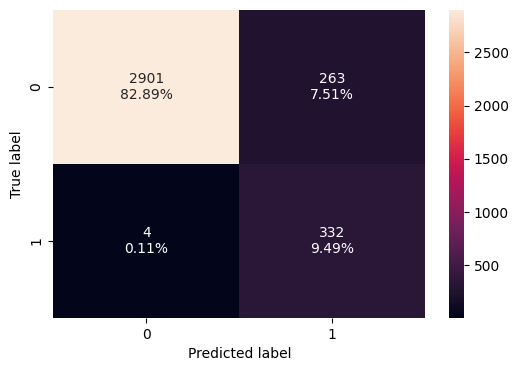

In [107]:
plot_confusion_matrix(model3, X_train, y_train)

In [108]:
decision_tree_tune_post_train = model_performance_classification(model3, X_train, y_train)
decision_tree_tune_post_train

,Accuracy,Recall,Precision,F1
0,0.923714,0.988095,0.557983,0.713212


**Visualizing the Decision Tree**

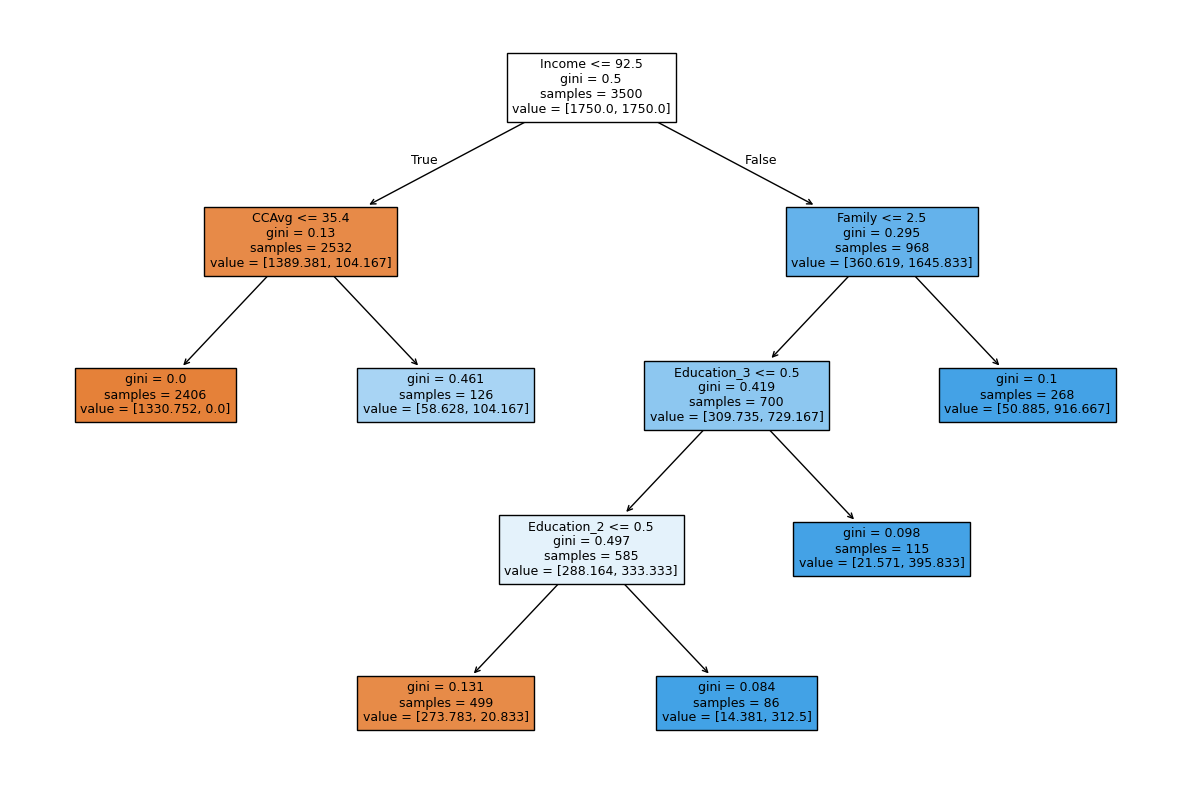

In [109]:
# list of feature names in X_train
feature_names = list(X_train.columns)

# set the figure size for the plot
plt.figure(figsize=(15, 10))

# plotting the decision tree
out = tree.plot_tree(
    model3,                         # decision tree classifier model
    feature_names=feature_names,    # list of feature names (columns) in the dataset
    filled=True,                    # fill the nodes with colors based on class
    fontsize=9,                     # font size for the node text
    node_ids=False,                 # do not show the ID of each node
    class_names=None,               # whether or not to display class names
)

# add arrows to the decision tree splits if they are missing
for o in out:
    arrow = o.arrow_patch
    if arrow is not None:
        arrow.set_edgecolor("black")    # set arrow color to black
        arrow.set_linewidth(1)          # set arrow linewidth to 1

# displaying the plot
plt.show()

In [110]:
# printing a text report showing the rules of a decision tree
print(
    tree.export_text(
        model3,    # specify the model
        feature_names=feature_names,    # specify the feature names
        show_weights=True    # specify whether or not to show the weights associated with the model
    )
)

|--- Income <= 92.50
|   |--- CCAvg <= 35.40
|   |   |--- weights: [1330.75, 0.00] class: 0
|   |--- CCAvg >  35.40
|   |   |--- weights: [58.63, 104.17] class: 1
|--- Income >  92.50
|   |--- Family <= 2.50
|   |   |--- Education_3 <= 0.50
|   |   |   |--- Education_2 <= 0.50
|   |   |   |   |--- weights: [273.78, 20.83] class: 0
|   |   |   |--- Education_2 >  0.50
|   |   |   |   |--- weights: [14.38, 312.50] class: 1
|   |   |--- Education_3 >  0.50
|   |   |   |--- weights: [21.57, 395.83] class: 1
|   |--- Family >  2.50
|   |   |--- weights: [50.88, 916.67] class: 1



In [111]:
# importance of features in the tree building ( The importance of a feature is computed as the
# (normalized) total reduction of the criterion brought by that feature. It is also known as the Gini importance )

print(
    pd.DataFrame(
        model3.feature_importances_, columns=["Imp"], index=X_train.columns
    ).sort_values(by="Imp", ascending=False)
)

                         Imp
Income              0.655545
Education_2         0.165072
CCAvg               0.080721
Education_3         0.057606
Family              0.041056
Age                 0.000000
CD_Account          0.000000
Securities_Account  0.000000
Mortgage            0.000000
CreditCard          0.000000
Online              0.000000
Zone_Zone_2         0.000000
Zone_Zone_3         0.000000
Zone_Zone_5         0.000000
Zone_Zone_4         0.000000
Zone_Zone_0         0.000000
Zone_Zone_6         0.000000


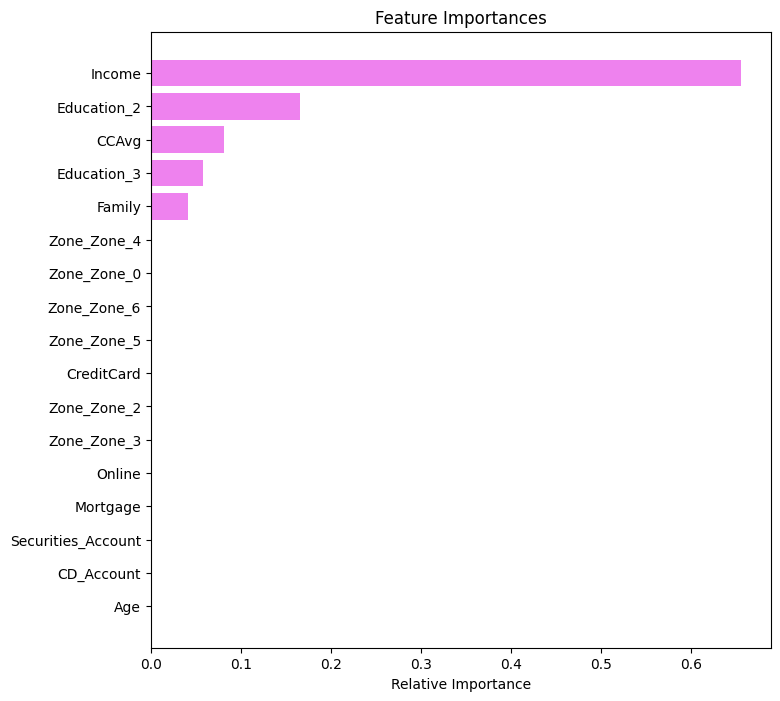

In [112]:
importances = model3.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(8, 8))
plt.title("Feature Importances")
plt.barh(range(len(indices)), importances[indices], color="violet", align="center")
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel("Relative Importance")
plt.show()

**Checking performance on test data**

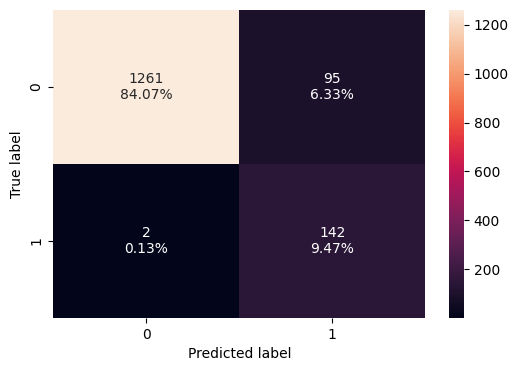

In [113]:
plot_confusion_matrix(model3, X_test, y_test)

In [114]:
decision_tree_tune_post_test = model_performance_classification(model3, X_test, y_test)
decision_tree_tune_post_test

,Accuracy,Recall,Precision,F1
0,0.935333,0.986111,0.599156,0.745407


## Model Performance Comparison and Final Model Selection

In [115]:
# training performance comparison

models_train_comp_df = pd.concat(
    [decision_tree_perf_train.T, decision_tree_bal_perf_train.T, decision_tree_tune_perf_train.T, decision_tree_tune_post_train.T], axis=1,
)
models_train_comp_df.columns = ["Decision Tree (sklearn default)", "Decision Tree (weighted)", "Decision Tree (Pre-Pruning)", "Decision Tree (Post-Pruning)"]
print("Training performance comparison:")
models_train_comp_df

Training performance comparison:


,Decision Tree (sklearn default),Decision Tree (weighted),Decision Tree (Pre-Pruning),Decision Tree (Post-Pruning)
Accuracy,1.0,1.0,0.783429,0.923714
Recall,1.0,1.0,1.000000,0.988095
Precision,1.0,1.0,0.307130,0.557983
F1,1.0,1.0,0.469930,0.713212


In [116]:
# testing performance comparison

models_test_comp_df = pd.concat(
    [decision_tree_perf_test.T, decision_tree_bal_perf_test.T, decision_tree_tune_perf_test.T, decision_tree_tune_post_test.T], axis=1,
)
models_test_comp_df.columns = ["Decision Tree (sklearn default)", "Decision Tree (weighted)", "Decision Tree (Pre-Pruning)", "Decision Tree (Post-Pruning)"]
print("Test set performance comparison:")
models_test_comp_df

Test set performance comparison:


,Decision Tree (sklearn default),Decision Tree (weighted),Decision Tree (Pre-Pruning),Decision Tree (Post-Pruning)
Accuracy,0.981333,0.980000,0.795333,0.935333
Recall,0.916667,0.888889,1.000000,0.986111
Precision,0.891892,0.901408,0.319290,0.599156
F1,0.904110,0.895105,0.484034,0.745407


- Both the pre-pruned and post-pruned decision trees exhibit generalized performances, have low complexity and are easy to understand and interpret.

- The pre-pruned decision tree has a Recall score of 1 on both training and testing; but Precision and F1 Scores are way too low.
    - Performance is slightly better on test set.
    - This model uses only three features for decision-making: Income, CCAvg and Family.
    - This will result in a low prediction time but it might not be able to perform well on edge cases in unseen data.

- The post-pruned decision tree has almost the same performance on training and test sets.
    - Recall Score is high, has a good F1 Score, and performance slightly better on test set.
    - This model uses a few more features for decision-making than the pre-pruned decision tree.
    - This will result in a slightly longer prediction time but it is likely to yield better results on unseen data.

- **Post-Pruning model (model3)** will be selected as final model due to high Recall Score, good F1 Score and high Accuracy.

### Predicting on a single data point

In [117]:
%%time
# choosing a data point
customer_details = X_test.iloc[11:12, :]

# making a prediction
purchase_prediction = model3.predict(customer_details)

print(purchase_prediction)

[1]
CPU times: total: 0 ns
Wall time: 1.13 ms


- The model was able to predict almost instantly.
- Instead of predicting a class (purchase/no loan), the model can also predict the likelihood of purchase.

In [118]:
# making a prediction

purchase_likelihood = model3.predict_proba(customer_details)

print(purchase_likelihood[0, 1])

0.9560067681895089


- This indicates that the model is 95.6% confident that the customer will purchase a loan.

## Actionable Insights and Business Recommendations


### Insights and Conclusions

* During the analysis of ZIP Code, all the addresses are from California, but it is possible that at least 6 customers have postal addresses related to the military.  This may have an impact on their purchase behaviour and  will yield False Positive results (they may have the right Income, Family, Education and CCAvg for the model parameters, but still will not purchase a loan due to external circumstances such as deployment or living outside CA).  It is recommended to the bank to either filter out addresses starting with 961 to 966, or to get a SME to better understand this specific market segment.

* It is important to change CCAVg monthly base to a yearly base in order to better compare expenditures and income.

* For the selected model the main feature is Income, followed by Education (Graduate), CCAvg, Education (Advanced/Professional) and Family.

* The class imbalance was reduced by capping outliers and using the "class_weight = 'balanced'" parameter. 

### Business Recommendations

* Target customers with high annual income: above 90K USD.  Also aim for Graduate and Professional education levels and 3 to 4 family members.

* For customers with annual income below 90K USD, aim for CCAvg greater than 35K USD (annually).

* Take advantage of digital channels for marketing and advertize in professional networks such as LinkedIn, in College and Universities websites, and other professional websites in the California area.

* Target owners of CD Accounts and offer the option to create a CD account with the loan offering for those with no CD account.

* Use the model's capability to predict likelihood of purchase to fine-tune and adjust marketing budgeting and resources.

___

Disclaimer: this notebook uses some of the code and structure from AIML_ML_Project_Low_Code_Notebook.ipynb and Hands_on_Decision_Tree_Notebook.ipynb; and some AI generated recommendations (for code) from Goggle Colab.